In [1]:
# %% Imports and config
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader, Subset
from sklearn.model_selection import KFold
from sklearn.preprocessing import MinMaxScaler
import copy
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt


# --- CONFIG ---
BATCH_SIZE = 256
EPOCHS = 25
LEARNING_RATE = 1e-5
KFOLDS = 5
TEST_SPLIT = 0.2
SEED = 217

torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
from torch.utils.data import Dataset
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import numpy as np
import torch
import os

class TimeSeriesDataset(Dataset):
    def __init__(self, csv_files, step=1, input_range=(-1, 1), target_range=(-1, 1), value_clip=1e3):
        self.data = []
        self.target = []

        print(f"📂 Processing {len(csv_files)} files")
        if not csv_files:
            raise ValueError("❌ No CSV files provided.")

        for file in csv_files:
            try:
                df = pd.read_csv(file)
                if df.shape[1] < 4:
                    print(f"⚠️ Skipping {file}: too few columns")
                    continue

                # Pretpostavka: kolone su [time, value, next_time, next_value]
                df = df.iloc[::step, :4]
                df.columns = ['time', 'value', 'next_time', 'next_value']

                time = df['time'].values
                next_time = df['next_time'].values
                value = df['value'].values
                next_value = df['next_value'].values

                # Čišćenje
                valid_mask = (
                    np.isfinite(time) & np.isfinite(next_time) &
                    np.isfinite(value) & np.isfinite(next_value) &
                    (np.abs(value) < value_clip) & (np.abs(next_value) < value_clip)
                )

                if not np.any(valid_mask):
                    print(f"⚠️ Skipping {file}: no valid rows after filtering")
                    continue

                time = time[valid_mask]
                next_time = next_time[valid_mask]
                dt = next_time - time
                value = value[valid_mask]
                next_value = next_value[valid_mask]

                # Novi ulazni format: [time, next_time, value]
                inputs = np.stack([dt, value], axis=1)
                self.data.append(inputs)
                self.target.append(next_value)

            except Exception as e:
                print(f"❌ Failed to process {file}: {e}")
                continue

        # ✅ Finalna obrada
        self.data = np.concatenate(self.data, axis=0)
        self.target = np.concatenate(self.target, axis=0)

        # Normalizacija
        self.scaler_X = MinMaxScaler(feature_range=input_range)
        self.scaler_y = MinMaxScaler(feature_range=target_range)

        self.data = self.scaler_X.fit_transform(self.data)
        self.target = self.scaler_y.fit_transform(self.target.reshape(-1, 1)).flatten()

        print(f"✅ Loaded {len(self.data)} samples from {len(csv_files)} files.")
        print(f"📊 Input shape: {self.data.shape}, Target shape: {self.target.shape}")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.data[idx], dtype=torch.float32),
            torch.tensor(self.target[idx], dtype=torch.float32)
        )

    def get_scalers(self):
        return self.scaler_X, self.scaler_y


In [3]:
class AdaptiveMixedActivation(nn.Module):
    def __init__(self, delta_init=0.0, epsilon_init=1.0):
        super().__init__()
        self.raw_delta = nn.Parameter(torch.tensor(float(delta_init)))
        self.raw_epsilon = nn.Parameter(torch.tensor(float(epsilon_init)))

    def forward(self, x):
        delta = self.raw_delta
        epsilon = self.raw_epsilon

        return (delta * torch.sin(epsilon * x))


In [4]:
import torch
import torch.nn as nn
import math

# === Custom Activation: Sine + Cosine Mixer ===
class SinCosActivation(nn.Module):
    def __init__(self, alpha=1.0, beta = 1):
        super().__init__()
        self.alpha = nn.Parameter(torch.tensor(alpha, dtype=torch.float32))
        self.beta  = nn.Parameter(torch.tensor(beta, dtype=torch.float32))


    def forward(self, x):
        return (torch.sin(self.alpha)*x + torch.cos(self.alpha)*x) * self.beta

# === Feedforward Network Using SinCos Activations ===
import torch.nn as nn

class FeedforwardNet(nn.Module):
    def __init__(self, input_size=2, hidden_layers=5, neurons_per_layer=32, output_size=1):
        super().__init__()

        layers = []
        prev_size = input_size

        for _ in range(hidden_layers):
            layers.append(nn.Linear(prev_size, neurons_per_layer))
            layers.append(SinCosActivation())  # Trenabilna aktivacija
            prev_size = neurons_per_layer

        layers.append(nn.Linear(prev_size, output_size))
        self.model = nn.Sequential(*layers)
        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.model(x)



In [5]:
# --- Nova Pick-One-Layer-Handles-Everything aktivacija ---
class AdaptiveMixedActivation(nn.Module):
    def __init__(self, delta_init=0.1, epsilon_init=0.1):
        super().__init__()
        self.raw_delta = nn.Parameter(torch.tensor(float(delta_init)))
        self.raw_epsilon = nn.Parameter(torch.tensor(float(epsilon_init)))

    def forward(self, x):
        delta = self.raw_delta
        epsilon = self.raw_epsilon

        return (delta * torch.sin(epsilon * x))


In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import copy

def train_fold(model, train_loader, val_loader, device=device, lr=0.00001, weight_decay=1e-6, patience=3):
    criterion = nn.MSELoss()
    optimizer = optim.RMSprop(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_model = None
    best_val_loss = float('inf')
    train_losses, val_losses = [], []
    epochs_without_improvement = 0

    # Log parametara aktivacione funkcije po epohi
    activation_logs = []

    for epoch in range(EPOCHS):
        model.train()
        train_loss = 0

        for i, (x, y) in enumerate(train_loader):
            optimizer.zero_grad()
            x, y = x.to(device), y.to(device)
            pred = model(x)
            y = y.view(-1, 1)

            mse = criterion(pred, y)
            peak_loss = (pred.max() - y.max()).pow(2)
            trough_loss = (pred.min() - y.min()).pow(2)
            loss = mse + 0.11 * peak_loss + 0.5 * trough_loss

            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        avg_train = train_loss / len(train_loader)
        train_losses.append(avg_train)

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                pred = model(x)
                y = y.view(-1, 1)

                mse = criterion(pred, y)
                peak_loss = (pred.max() - y.max()).pow(2)
                trough_loss = (pred.min() - y.min()).pow(2)
                loss = mse + 0.0 * peak_loss + 0.0 * trough_loss

                val_loss += loss.item()

        avg_val = val_loss / len(val_loader)
        val_losses.append(avg_val)

        # === LOGOVANJE AKTIVACIONIH PARAMETARA ===
        epoch_params = []
        for module in model.modules():
            if isinstance(module, AdaptiveMixedActivation):
                epoch_params.append({
                    'alpha': module.raw_alpha.item(),
                    'beta': module.raw_beta.item()
                })
        activation_logs.append(epoch_params)

        print(f"Epoch {epoch+1}: Train {avg_train:.4f} | Val {avg_val:.4f}")
        for idx, p in enumerate(epoch_params):
            print(f"  ↪ Layer {idx+1} params: alpha={p['alpha']:.4f}, beta={p['beta']:.4f}")

        if avg_val < best_val_loss:
            best_val_loss = avg_val
            best_model = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            print(f"⚠️ Early stopping at epoch {epoch+1} due to no improvement in validation loss.")
            break

    # Aktivacione parametre možeš vratiti zasebno ako želiš u analizi (ali ih ovde ne menjamo)
    return best_model, best_val_loss, train_losses, val_losses


In [7]:
def cross_validate(dataset, hidden_layers=5, neurons_per_layer=32):
    indices = np.arange(len(dataset))
    np.random.shuffle(indices)
    test_size = int(TEST_SPLIT * len(indices))
    test_set = Subset(dataset, indices[:test_size])
    train_val_set = Subset(dataset, indices[test_size:])

    kfold = KFold(n_splits=KFOLDS, shuffle=True, random_state=SEED)

    all_train, all_val = [], []
    best_model = None
    best_loss = float("inf")

    for fold, (train_idx, val_idx) in enumerate(kfold.split(range(len(train_val_set)))):
        print(f"\n--- Fold {fold+1} ---")
        train_subset = Subset(train_val_set, train_idx)
        val_subset = Subset(train_val_set, val_idx)

        train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True)
        val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE)

        model = FeedforwardNet(
            input_size=2,
            hidden_layers=hidden_layers,
            neurons_per_layer=neurons_per_layer
        ).to(device)

        model_fold, val_loss, train_losses, val_losses = train_fold(model, train_loader, val_loader)

        all_train.append(train_losses)
        all_val.append(val_losses)

        if val_loss < best_loss:
            best_model = model_fold
            best_loss = val_loss

    return best_model, test_set, all_train, all_val


In [8]:
def plot_avg_loss_curves(train_losses, val_losses):
    max_len = max(len(t) for t in train_losses)

    def pad_with_nan(lst, target_len):
        return lst + [np.nan] * (target_len - len(lst))

    padded_train = np.array([pad_with_nan(t, max_len) for t in train_losses])
    padded_val = np.array([pad_with_nan(v, max_len) for v in val_losses])

    avg_train = np.nanmean(padded_train, axis=0)
    avg_val = np.nanmean(padded_val, axis=0)

    plt.figure(figsize=(10, 5))
    plt.plot(avg_train, label="Avg Train Loss")
    plt.plot(avg_val, label="Avg Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.title("Cross-Validation Loss Curves")
    plt.legend()
    plt.grid(True)
    plt.show()

def evaluate_and_visualize(model, test_set, dataset, device, start=0, window=None):
    model.eval()
    test_loader = DataLoader(test_set, batch_size=64)
    predictions, truths = [], []

    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            pred = model(x).squeeze().cpu().numpy()
            y = y.cpu().numpy()
            
            # Convert predictions and truths back to original scale
            pred = dataset.scaler_y.inverse_transform(pred.reshape(-1, 1)).flatten()
            y = dataset.scaler_y.inverse_transform(y.reshape(-1, 1)).flatten()
            
            truths.extend(y)
            predictions.extend(pred)

    # Apply slicing based on start and window
    end = start + window if window is not None else None
    sliced_preds = predictions[start:end]
    sliced_truths = truths[start:end]

    # Plot selected window
    plt.figure(figsize=(12, 6))
    plt.plot(sliced_truths, label='True')
    plt.plot(sliced_preds, label='Predicted', alpha=0.7)
    plt.legend()
    plt.title(f"Forecast vs Ground Truth (start={start}, window={window})")
    plt.xlabel("Time Step")
    plt.ylabel("Value")
    plt.grid(True)
    plt.show()

    # Print full MSE regardless of window
    mse = np.mean((np.array(truths) - np.array(predictions))**2)
    print(f"\nFinal Test MSE (full set): {mse:.4f}")



In [9]:
if __name__ == "__main__":
    # Try different file name patterns - adjust this based on your actual file names
    patterns = ["rectifier*.csv", "fil*.csv", "*.csv"]
    
    for pattern in patterns:
        base = pattern.split("*")[0]
        csv_files = [f for f in os.listdir() if f.endswith("1e-5.csv") 
                     and f.startswith("new_rectifier") 
                     ]
        if csv_files:
            print(f"Found {len(csv_files)} files with pattern '{pattern}'")
            break
    
    if not csv_files:
        print("No CSV files found. Please check your directory.")
        # List all files in directory for debugging
        print("Files in directory:", os.listdir())
        exit(1)
    
    #csv_files = ["filtered_modified_data_logger_R1000_C1.5e-05.csv"]
    # Create dataset
    dataset = TimeSeriesDataset(csv_files)

    print(csv_files)

    # After cross-validation
    best_model_state_dict, test_set, train_losses, val_losses = cross_validate(dataset, hidden_layers=9, neurons_per_layer=48)


Found 96 files with pattern 'rectifier*.csv'
📂 Processing 96 files
✅ Loaded 2879904 samples from 96 files.
📊 Input shape: (2879904, 2), Target shape: (2879904,)
['new_rectifier_results_R=1.5915494309189535_C=0.0001__time_step_1e-5.csv', 'new_rectifier_results_R=1.5915494309189535_C=0.001__time_step_1e-5.csv', 'new_rectifier_results_R=1.5915494309189535_C=1e-05__time_step_1e-5.csv', 'new_rectifier_results_R=1.5915494309189535_C=1e-06__time_step_1e-5.csv', 'new_rectifier_results_R=1.6753151904410035_C=0.0001__time_step_1e-5.csv', 'new_rectifier_results_R=1.6753151904410035_C=0.001__time_step_1e-5.csv', 'new_rectifier_results_R=1.6753151904410035_C=1e-05__time_step_1e-5.csv', 'new_rectifier_results_R=1.6753151904410035_C=1e-06__time_step_1e-5.csv', 'new_rectifier_results_R=1.768388256576615_C=0.0001__time_step_1e-5.csv', 'new_rectifier_results_R=1.768388256576615_C=0.001__time_step_1e-5.csv', 'new_rectifier_results_R=1.768388256576615_C=1e-05__time_step_1e-5.csv', 'new_rectifier_results_R

C:\Users\OgnjenPeric\AppData\Local\Temp\ipykernel_2400\319708768.py:36: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\Scalar.cpp:23.)
  train_loss += loss.item()


Epoch 1: Train 0.0039 | Val 0.0003


KeyboardInterrupt: 

In [ ]:
print([type(m) for m in model.modules()])

NameError: name 'model' is not defined


✅ Model saved as 'rectifier_sine_cosine_all_R-C_pairs_model'


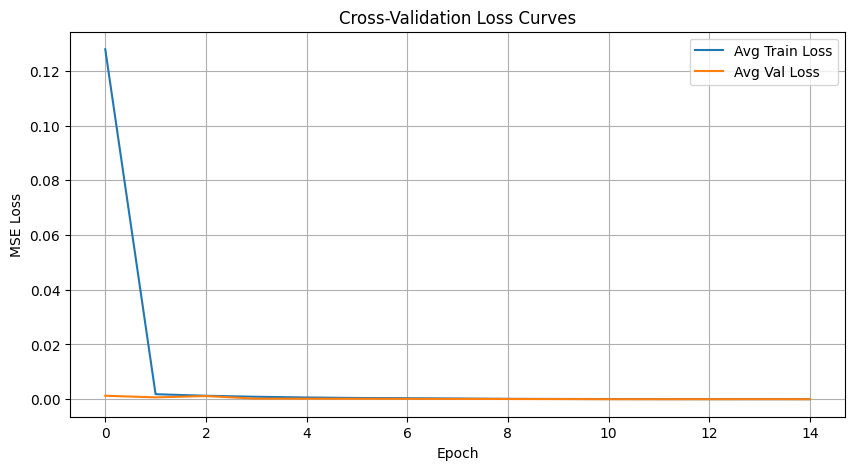

In [ ]:
# Initialize a new model object with the correct input size
model = FeedforwardNet(input_size=2, hidden_layers=9, neurons_per_layer=48).to(device)

# Load the best model's state dictionary into the model
model.load_state_dict(best_model_state_dict)

# Save the model
torch.save(model.state_dict(), "rectifier_sine_cosine_all_R-C_pairs_model__V(t)_h.pth")
print("\n✅ Model saved as 'rectifier_sine_cosine_all_R-C_pairs_model'")

# Evaluate and visualize the results
plot_avg_loss_curves(train_losses, val_losses)
#evaluate_and_visualize(model, test_set, dataset, device, start=0, window=100)


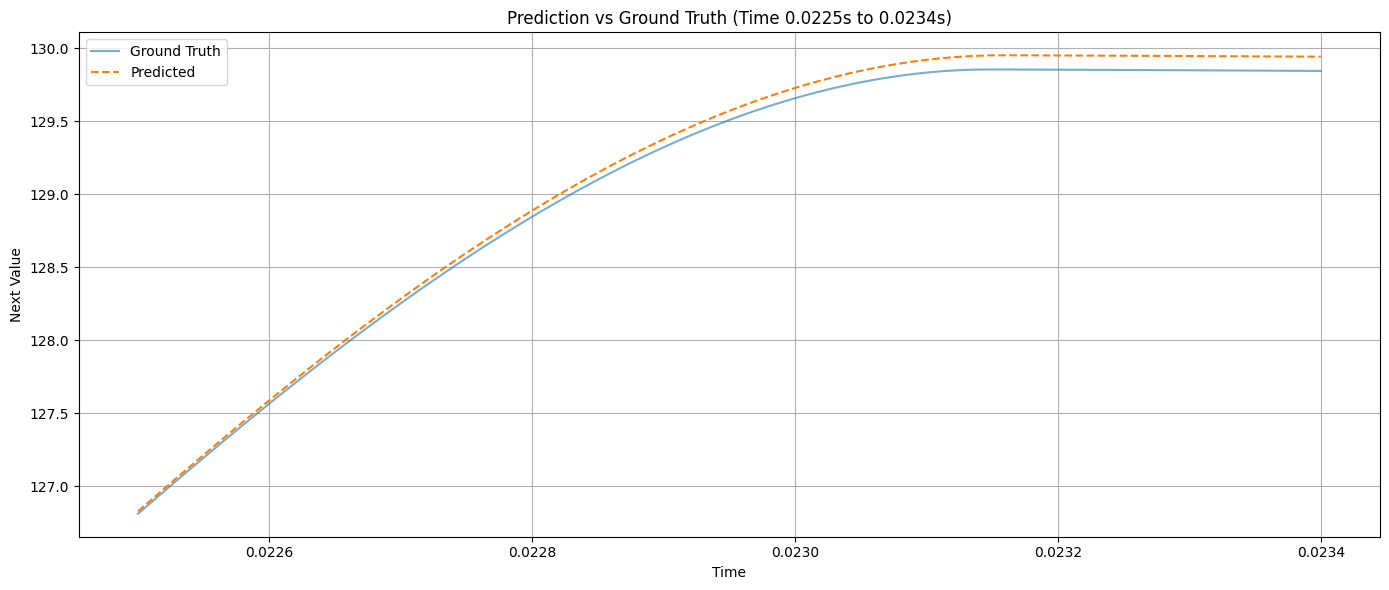

In [ ]:
import torch
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

model = FeedforwardNet(input_size=2, hidden_layers=9, neurons_per_layer=48).to(device)
# Load your trained model
model.load_state_dict(torch.load("rectifier_sine_cosine_all_R-C_pairs_model__V(t)_h.pth"))
model.eval()

# Load dataset
df = pd.read_csv("new_rectifier_results_R=18.724110951987686_C=0.0001__time_step_1e-5.csv")

# Prepare inputs
value = df["value"].values.astype("float32")
time = df["time"].values.astype("float32")
next_time = df["next_time"].values.astype("float32")
delta_t = next_time - time
X_all = np.stack([delta_t, value, ], axis=1).astype("float32")

# Ground truth
y_true_all = df["next_value"].values.astype("float32")


scaler_X, scaler_y = dataset.get_scalers()

# y_pred_tensor je 1D NumPy niz sa skaliranim predikcijama

# isto i za ground truth:
y_true_denorm = scaler_y.inverse_transform(y_true_all.reshape(-1, 1)).flatten()

# Convert to tensor and predict
X_tensor = torch.tensor(X_all)
with torch.no_grad():
    y_pred_tensor = model(X_tensor).squeeze().cpu().numpy()
y_pred_denorm = scaler_y.inverse_transform(y_pred_tensor.reshape(-1, 1)).flatten()

# === Custom Time Window ===
start_time = 0.0225
end_time = 0.0234

# Filter by time window using `next_time`
mask = (next_time >= start_time) & (next_time <= end_time)

# Plot
plt.figure(figsize=(14, 6))
plt.plot(next_time[mask], y_true_all[mask], label="Ground Truth", alpha=0.6)
plt.plot(next_time[mask], y_pred_tensor[mask], label="Predicted", linestyle="--")

plt.xlabel("Time")
plt.ylabel("Next Value")
plt.title(f"Prediction vs Ground Truth (Time {start_time}s to {end_time}s)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


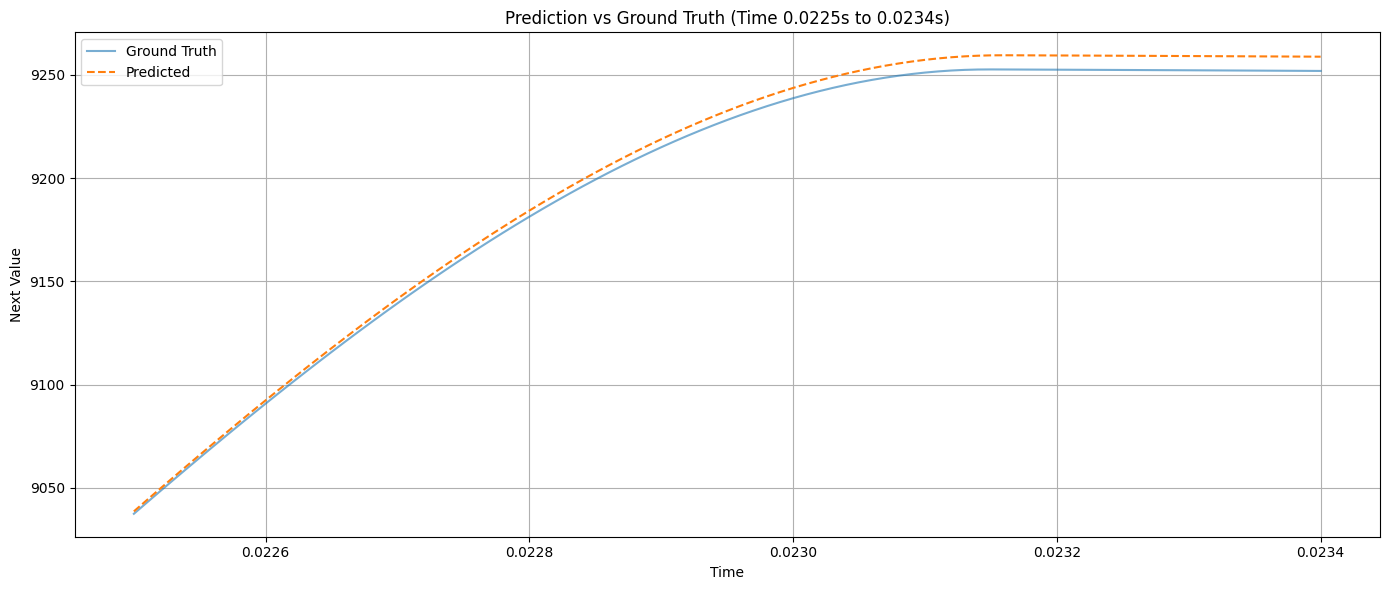

In [ ]:
import torch
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

model = FeedforwardNet(input_size=2, hidden_layers=9, neurons_per_layer=48).to(device)
# Load your trained model
model.load_state_dict(torch.load("rectifier_sine_cosine_all_R-C_pairs_model__V(t)_h.pth"))
model.eval()

# Load dataset
df = pd.read_csv("new_rectifier_results_R=18.724110951987686_C=0.0001__time_step_1e-5.csv")

# Prepare inputs
value = df["value"].values.astype("float32")
time = df["time"].values.astype("float32")
next_time = df["next_time"].values.astype("float32")
delta_t = next_time - time
X_all = np.stack([delta_t, value, ], axis=1).astype("float32")

# Ground truth
y_true_all = df["next_value"].values.astype("float32")


scaler_X, scaler_y = dataset.get_scalers()

# y_pred_tensor je 1D NumPy niz sa skaliranim predikcijama
y_pred_denorm = scaler_y.inverse_transform(y_pred_tensor.reshape(-1, 1)).flatten()

# isto i za ground truth:
y_true_denorm = scaler_y.inverse_transform(y_true_all.reshape(-1, 1)).flatten()

# Convert to tensor and predict
X_tensor = torch.tensor(X_all)
with torch.no_grad():
    y_pred_tensor = model(X_tensor).squeeze().cpu().numpy()

# === Custom Time Window ===
start_time = 0.0225
end_time = 0.0234

# Filter by time window using `next_time`
mask = (next_time >= start_time) & (next_time <= end_time)

# Plot
plt.figure(figsize=(14, 6))
plt.plot(next_time[mask], y_true_denorm[mask], label="Ground Truth", alpha=0.6)
plt.plot(next_time[mask], y_pred_denorm[mask], label="Predicted", linestyle="--")

plt.xlabel("Time")
plt.ylabel("Next Value")
plt.title(f"Prediction vs Ground Truth (Time {start_time}s to {end_time}s)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


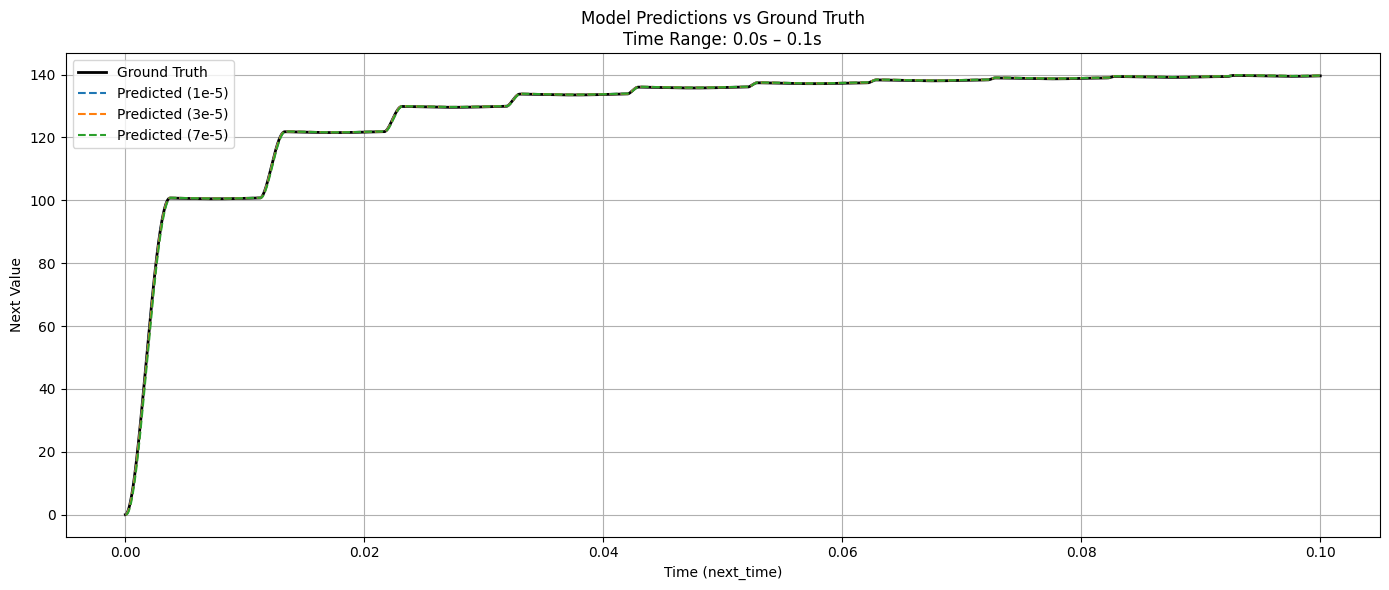

In [ ]:
import torch
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Load your trained model
model = FeedforwardNet(hidden_layers=9, neurons_per_layer=48, input_size=2, output_size=1)
model.load_state_dict(torch.load("rectifier_sine_cosine_all_R-C_pairs_model__V(t)_h.pth"))
model.eval()

# Dataset list
df_list = [
    'new_rectifier_results_R=18.724110951987686_C=0.0001__time_step_1e-5.csv',
    'new_rectifier_results_R=18.724110951987686_C=0.0001__time_step_3e-5.csv',
    'new_rectifier_results_R=18.724110951987686_C=0.0001__time_step_7e-5.csv'
]

# Custom time window
start_time = 0.0
end_time = 0.1

plt.figure(figsize=(14, 6))

# === Plot Ground Truth from the highest resolution file ===
ground_truth_df = pd.read_csv(df_list[0])
gt_next_time = ground_truth_df["next_time"].values.astype("float32")
gt_next_value = ground_truth_df["next_value"].values.astype("float32")
gt_mask = (gt_next_time >= start_time) & (gt_next_time <= end_time)
plt.plot(gt_next_time[gt_mask], gt_next_value[gt_mask], label="Ground Truth", color="black", linewidth=2)

# === Loop over all datasets and predict ===
for f in df_list:
    label = f.split("_time_step_")[-1].replace(".csv", "")

    df = pd.read_csv(f)
    time = df["time"].values.astype("float32")
    value = df["value"].values.astype("float32")
    next_time = df["next_time"].values.astype("float32")
    delta_t = next_time - time
    X_all = np.stack([delta_t, value, ], axis=1).astype("float32")
    
    # Predict
    with torch.no_grad():
        y_pred_tensor = model(torch.tensor(X_all)).squeeze().cpu().numpy()

    # Filter time window
    mask = (next_time >= start_time) & (next_time <= end_time)
    plt.plot(next_time[mask], y_pred_tensor[mask], linestyle="--", label=f"Predicted ({label})")

# === Final formatting ===
plt.title(f"Model Predictions vs Ground Truth\nTime Range: {start_time}s – {end_time}s")
plt.xlabel("Time (next_time)")
plt.ylabel("Next Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# === Configuration ===
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
csv_files = ['new_rectifier_results_R=1989.436788648692_C=0.0001__time_step_1e-5.csv', 
'new_rectifier_results_R=212.20659078919374_C=1e-06__time_step_1e-5.csv', 
'new_rectifier_results_R=198.94367886486916_C=0.0001__time_step_1e-5.csv', 
'new_rectifier_results_R=17.683882565766147_C=1e-05__time_step_1e-5.csv', 
'new_rectifier_results_R=1675.3151904410036_C=0.0001__time_step_1e-5.csv', 
'new_rectifier_results_R=17.683882565766147_C=0.001__time_step_1e-5.csv', 
'new_rectifier_results_R=2.1220659078919377_C=1e-05__time_step_1e-5.csv', 
'new_rectifier_results_R=1.6753151904410035_C=0.0001__time_step_1e-5.csv', 
'new_rectifier_results_R=159.15494309189532_C=0.0001__time_step_1e-5.csv', 
'new_rectifier_results_R=1.9894367886486917_C=0.001__time_step_1e-5.csv', 
'new_rectifier_results_R=21.22065907891938_C=0.0001__time_step_1e-5.csv', 
'new_rectifier_results_R=19.89436788648692_C=1e-05__time_step_1e-5.csv', 
'new_rectifier_results_R=167.53151904410035_C=0.0001__time_step_1e-5.csv', 
'new_rectifier_results_R=1591.5494309189535_C=0.0001__time_step_1e-5.csv', 
'new_rectifier_results_R=159.15494309189532_C=1e-06__time_step_1e-5.csv', 
'new_rectifier_results_R=176.83882565766146_C=0.001__time_step_1e-5.csv', 
'new_rectifier_results_R=21.22065907891938_C=0.001__time_step_1e-5.csv', 
'new_rectifier_results_R=18.724110951987686_C=0.0001__time_step_1e-5.csv', 
'new_rectifier_results_R=1.6753151904410035_C=1e-05__time_step_1e-5.csv', 
'new_rectifier_results_R=212.20659078919374_C=0.001__time_step_1e-5.csv', 
'new_rectifier_results_R=1989.436788648692_C=1e-06__time_step_1e-5.csv', 
'new_rectifier_results_R=21.22065907891938_C=1e-06__time_step_1e-5.csv', 
'new_rectifier_results_R=1.768388256576615_C=1e-05__time_step_1e-5.csv', 
'new_rectifier_results_R=2.1220659078919377_C=0.0001__time_step_1e-5.csv', 
'new_rectifier_results_R=18.724110951987686_C=0.001__time_step_1e-5.csv', 
'new_rectifier_results_R=198.94367886486916_C=1e-05__time_step_1e-5.csv', 
'new_rectifier_results_R=187.24110951987686_C=0.001__time_step_1e-5.csv', 
'new_rectifier_results_R=2.1220659078919377_C=1e-06__time_step_1e-5.csv', 
'new_rectifier_results_R=187.24110951987686_C=1e-05__time_step_1e-5.csv', 
'new_rectifier_results_R=19.89436788648692_C=0.0001__time_step_1e-5.csv', 
'new_rectifier_results_R=176.83882565766146_C=1e-05__time_step_1e-5.csv', 
'new_rectifier_results_R=1872.4110951987689_C=0.0001__time_step_1e-5.csv', 
'new_rectifier_results_R=16.753151904410036_C=1e-05__time_step_1e-5.csv', 
'new_rectifier_results_R=176.83882565766146_C=0.0001__time_step_1e-5.csv', 
'new_rectifier_results_R=1591.5494309189535_C=0.001__time_step_1e-5.csv', 
'new_rectifier_results_R=18.724110951987686_C=1e-06__time_step_1e-5.csv', 
'new_rectifier_results_R=2.1220659078919377_C=0.001__time_step_1e-5.csv', 
'new_rectifier_results_R=15.915494309189533_C=1e-05__time_step_1e-5.csv', 
'new_rectifier_results_R=1675.3151904410036_C=0.001__time_step_1e-5.csv', 
'new_rectifier_results_R=18.724110951987686_C=1e-05__time_step_1e-5.csv', 
'new_rectifier_results_R=1768.388256576615_C=0.0001__time_step_1e-5.csv', 
'new_rectifier_results_R=1872.4110951987689_C=1e-06__time_step_1e-5.csv', 
'new_rectifier_results_R=16.753151904410036_C=1e-06__time_step_1e-5.csv', 
'new_rectifier_results_R=176.83882565766146_C=1e-06__time_step_1e-5.csv', 
'new_rectifier_results_R=198.94367886486916_C=0.001__time_step_1e-5.csv', 
'new_rectifier_results_R=167.53151904410035_C=1e-06__time_step_1e-5.csv', 
'new_rectifier_results_R=167.53151904410035_C=1e-05__time_step_1e-5.csv', 
'new_rectifier_results_R=1768.388256576615_C=0.001__time_step_1e-5.csv', 
'new_rectifier_results_R=17.683882565766147_C=1e-06__time_step_1e-5.csv', 
'new_rectifier_results_R=1675.3151904410036_C=1e-06__time_step_1e-5.csv', 
'new_rectifier_results_R=1.9894367886486917_C=0.0001__time_step_1e-5.csv',
'new_rectifier_results_R=1.5915494309189535_C=0.0001__time_step_1e-5.csv', 
'new_rectifier_results_R=15.915494309189533_C=0.0001__time_step_1e-5.csv', 
'new_rectifier_results_R=159.15494309189532_C=1e-05__time_step_1e-5.csv', 
'new_rectifier_results_R=15.915494309189533_C=1e-06__time_step_1e-5.csv', 
'new_rectifier_results_R=159.15494309189532_C=0.001__time_step_1e-5.csv', 
'new_rectifier_results_R=167.53151904410035_C=0.001__time_step_1e-5.csv', 
'new_rectifier_results_R=1872.4110951987689_C=0.001__time_step_1e-5.csv', 
'new_rectifier_results_R=16.753151904410036_C=0.001__time_step_1e-5.csv', 
'new_rectifier_results_R=1.872411095198769_C=0.0001__time_step_1e-5.csv',
'new_rectifier_results_R=1591.5494309189535_C=1e-05__time_step_1e-5.csv',
'new_rectifier_results_R=1989.436788648692_C=1e-05__time_step_1e-5.csv', 
'new_rectifier_results_R=2122.065907891938_C=0.001__time_step_1e-5.csv', 
'new_rectifier_results_R=1.5915494309189535_C=1e-05__time_step_1e-5.csv', 
'new_rectifier_results_R=198.94367886486916_C=1e-06__time_step_1e-5.csv', 
'new_rectifier_results_R=212.20659078919374_C=0.0001__time_step_1e-5.csv', 
'new_rectifier_results_R=1675.3151904410036_C=1e-05__time_step_1e-5.csv', 
'new_rectifier_results_R=187.24110951987686_C=1e-06__time_step_1e-5.csv', 
'new_rectifier_results_R=1.768388256576615_C=0.0001__time_step_1e-5.csv', 
'new_rectifier_results_R=2122.065907891938_C=1e-06__time_step_1e-5.csv',
'new_rectifier_results_R=1.872411095198769_C=0.001__time_step_1e-5.csv', 
'new_rectifier_results_R=1.872411095198769_C=1e-06__time_step_1e-5.csv', 
'new_rectifier_results_R=1.872411095198769_C=1e-05__time_step_1e-5.csv', 
'new_rectifier_results_R=1.5915494309189535_C=0.001__time_step_1e-5.csv',
'new_rectifier_results_R=1.6753151904410035_C=1e-06__time_step_1e-5.csv', 
'new_rectifier_results_R=19.89436788648692_C=0.001__time_step_1e-5.csv', 
'new_rectifier_results_R=1872.4110951987689_C=1e-05__time_step_1e-5.csv',
'new_rectifier_results_R=1.5915494309189535_C=1e-06__time_step_1e-5.csv',
'new_rectifier_results_R=1768.388256576615_C=1e-06__time_step_1e-5.csv',
'new_rectifier_results_R=212.20659078919374_C=1e-05__time_step_1e-5.csv', 
'new_rectifier_results_R=1.6753151904410035_C=0.001__time_step_1e-5.csv', 
'new_rectifier_results_R=187.24110951987686_C=0.0001__time_step_1e-5.csv', 
'new_rectifier_results_R=19.89436788648692_C=1e-06__time_step_1e-5.csv', 
'new_rectifier_results_R=1768.388256576615_C=1e-05__time_step_1e-5.csv', 
'new_rectifier_results_R=2122.065907891938_C=1e-05__time_step_1e-5.csv', 
'new_rectifier_results_R=1.768388256576615_C=0.001__time_step_1e-5.csv', 
'new_rectifier_results_R=21.22065907891938_C=1e-05__time_step_1e-5.csv', 
'new_rectifier_results_R=15.915494309189533_C=0.001__time_step_1e-5.csv',
'new_rectifier_results_R=1.768388256576615_C=1e-06__time_step_1e-5.csv', 
'new_rectifier_results_R=2122.065907891938_C=0.0001__time_step_1e-5.csv', 
'new_rectifier_results_R=1591.5494309189535_C=1e-06__time_step_1e-5.csv', 
'new_rectifier_results_R=16.753151904410036_C=0.0001__time_step_1e-5.csv', 
'new_rectifier_results_R=1.9894367886486917_C=1e-06__time_step_1e-5.csv', 
'new_rectifier_results_R=1.9894367886486917_C=1e-05__time_step_1e-5.csv', 
'new_rectifier_results_R=17.683882565766147_C=0.0001__time_step_1e-5.csv', 
'new_rectifier_results_R=1989.436788648692_C=0.001__time_step_1e-5.csv']


dataset = TimeSeriesDataset(csv_files)

hidden_layer_options = [5, 9, 13]
width_options = [32, 48, 64]
results = []

# === Training and Evaluation Loop ===
for hidden_layers in hidden_layer_options:
    for neurons_per_layer in width_options:
        print(f"🚀 Training model with {hidden_layers} layers and {neurons_per_layer} neurons/layer")
        
        model, test_set, train_losses, val_losses = cross_validate(dataset, hidden_layers, neurons_per_layer)
        
        # Save state_dict
        model_path = f"model_L{hidden_layers}_W{neurons_per_layer}_RC_pairs.pth"
        torch.save(model, model_path)


        # Recreate model with correct architecture for loading
        model_loaded = FeedforwardNet(input_size=2, hidden_layers=hidden_layers, neurons_per_layer=neurons_per_layer)
        model_loaded.load_state_dict(torch.load(model_path))
        model_loaded.eval()

        # Evaluate
        test_loader = torch.utils.data.DataLoader(test_set, batch_size=len(test_set), shuffle=False)
        x_test, y_test = next(iter(test_loader))

        with torch.no_grad():
            y_pred = model_loaded(x_test).squeeze().cpu().numpy()
        y_true = y_test.numpy()
        mse = mean_squared_error(y_true, y_pred)

        results.append({
            "layers": hidden_layers,
            "width": neurons_per_layer,
            "mse": mse,
            "next_time": x_test[:, 2].numpy(),  # Assuming column 2 is next_time
            "true": y_true,
            "pred": y_pred
        })


📂 Processing 96 files
⚠️ Skipping new_rectifier_results_R=1989.436788648692_C=0.0001__time_step_1e-5.csv: no valid rows after filtering
⚠️ Skipping new_rectifier_results_R=21.22065907891938_C=0.0001__time_step_1e-5.csv: no valid rows after filtering
⚠️ Skipping new_rectifier_results_R=19.89436788648692_C=1e-05__time_step_1e-5.csv: no valid rows after filtering
⚠️ Skipping new_rectifier_results_R=159.15494309189532_C=1e-06__time_step_1e-5.csv: no valid rows after filtering
⚠️ Skipping new_rectifier_results_R=21.22065907891938_C=1e-06__time_step_1e-5.csv: no valid rows after filtering
⚠️ Skipping new_rectifier_results_R=2.1220659078919377_C=1e-06__time_step_1e-5.csv: no valid rows after filtering
⚠️ Skipping new_rectifier_results_R=1872.4110951987689_C=0.0001__time_step_1e-5.csv: no valid rows after filtering
⚠️ Skipping new_rectifier_results_R=176.83882565766146_C=0.0001__time_step_1e-5.csv: no valid rows after filtering
⚠️ Skipping new_rectifier_results_R=176.83882565766146_C=1e-06__ti

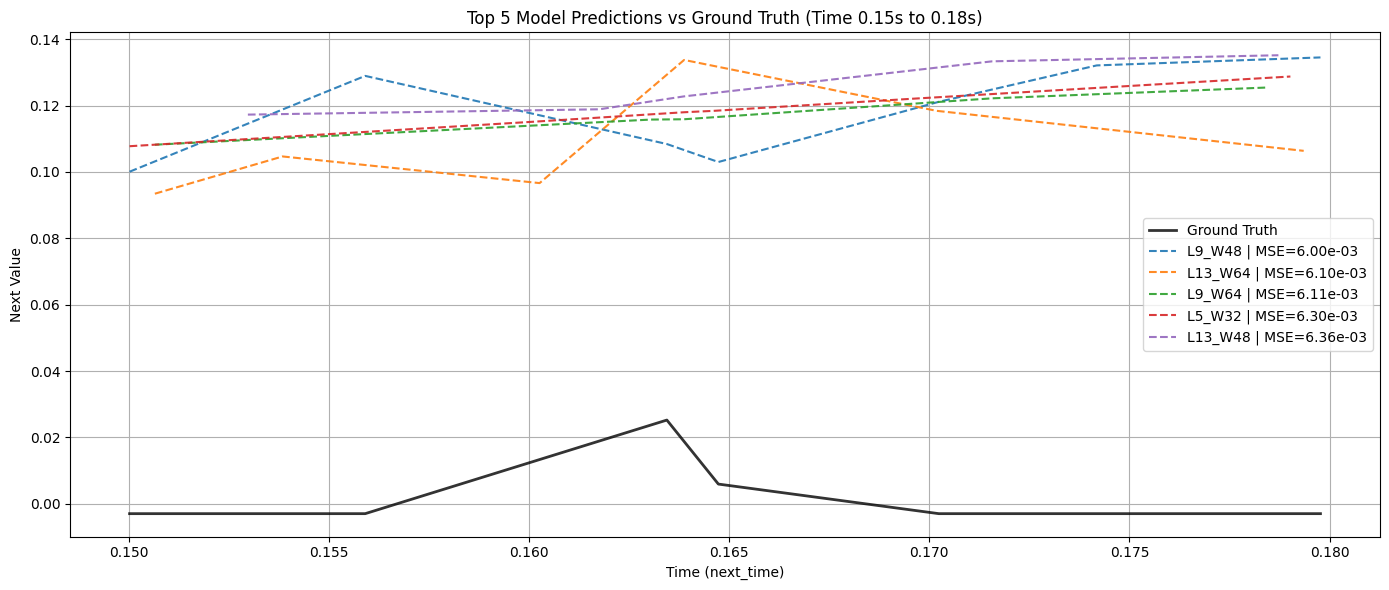

In [ ]:
# === Define time window ===
start_time = 0.15
end_time = 0.18

# === Sort and Pick Top 5 ===
top_models = sorted(results, key=lambda r: r["mse"])[:5]

# === Create Plot ===
plt.figure(figsize=(14, 6))

# === Ground Truth (with time mask and downsampling) ===
next_time = top_models[0]["next_time"]
y_true = top_models[0]["true"]

# Apply mask
mask = (next_time >= start_time) & (next_time <= end_time)
masked_time = next_time[mask]
masked_true = y_true[mask]

# Sort and downsample
idx_sorted = np.argsort(masked_time)
downsampled_idx = idx_sorted[::10]

plt.plot(
    masked_time[downsampled_idx],
    masked_true[downsampled_idx],
    label="Ground Truth",
    color="black",
    linewidth=2,
    alpha=0.8,
)

# === Model Predictions (masked + downsampled) ===
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple"]
for i, r in enumerate(top_models):
    next_time = r["next_time"]
    pred = r["pred"]

    mask = (next_time >= start_time) & (next_time <= end_time)
    masked_time = next_time[mask]
    masked_pred = pred[mask]

    idx_sorted = np.argsort(masked_time)
    downsampled_idx = idx_sorted[::10]

    label = f"L{r['layers']}_W{r['width']} | MSE={r['mse']:.2e}"
    
    plt.plot(
        masked_time[downsampled_idx],
        masked_pred[downsampled_idx],
        label=label,
        linestyle="--",
        color=colors[i % len(colors)],
        alpha=0.9
    )

# === Final Touches ===
plt.title(f"Top 5 Model Predictions vs Ground Truth (Time {start_time}s to {end_time}s)")
plt.xlabel("Time (next_time)")
plt.ylabel("Next Value")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
import plotly.graph_objs as go
from plotly.subplots import make_subplots
import numpy as np

# === Sort and Pick Top 5 ===
top_models = sorted(results, key=lambda r: r["mse"])[:5]

# === Subplot Layout (1 row per model) ===
fig = make_subplots(
    rows=5, cols=1,
    shared_xaxes=True,
    vertical_spacing=0.03,
    subplot_titles=[f"L{r['layers']}_W{r['width']} | MSE={r['mse']:.2e}" for r in top_models]
)

# === Add traces ===
for i, r in enumerate(top_models):
    idx = np.argsort(r["next_time"])
    t = r["next_time"][idx]
    y_true = r["true"][idx]
    y_pred = r["pred"][idx]

    fig.add_trace(go.Scatter(x=t, y=y_true, mode="lines", name="Ground Truth",
                             line=dict(color="black", width=2), showlegend=(i == 0)),
                  row=i+1, col=1)

    fig.add_trace(go.Scatter(x=t, y=y_pred, mode="lines", name="Predicted",
                             line=dict(dash="dash", width=2), showlegend=(i == 0)),
                  row=i+1, col=1)

# === Layout ===
fig.update_layout(
    height=1200,
    title_text="Top 5 Model Predictions vs Ground Truth (Interactive)",
    hovermode="x unified",
    legend=dict(y=1.02, orientation="h"),
    margin=dict(t=100),
)

fig.update_xaxes(title_text="Time (next_time)", row=5, col=1)
fig.update_yaxes(title_text="Next Value")

fig.write_html("top5_models_plot_R-C_pairs.html")

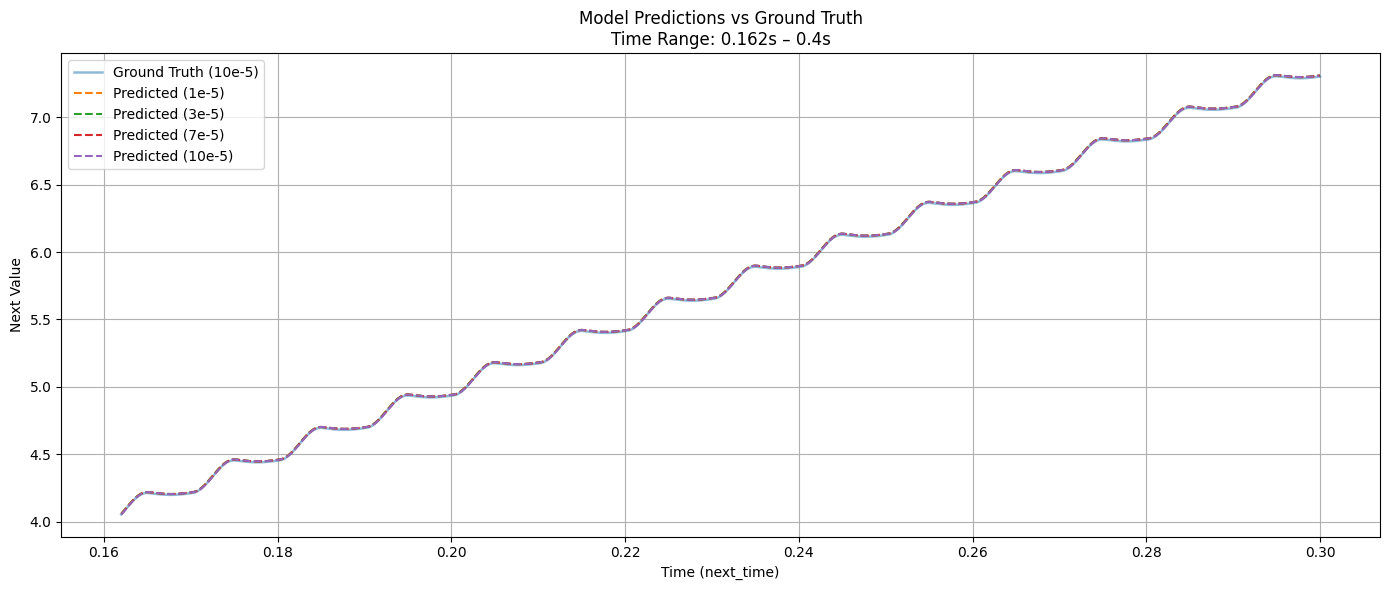

In [ ]:
import torch
import matplotlib.pyplot as plt
import pandas as pd

# Load your trained model
model = FeedforwardNet(hidden_layers=9, neurons_per_layer=48, input_size=2, output_size=1)
model.load_state_dict(torch.load("rectifier_sine_cosine_all_R-C_pairs_model__V(t)_h.pth"))
model.eval()

# Dataset list
df_list = [
    'new_rectifier_results_R=1768.388256576615_C=0.001__time_step_1e-5.csv',
    'new_rectifier_results_R=1768.388256576615_C=0.001__time_step_3e-5.csv',
    'new_rectifier_results_R=1768.388256576615_C=0.001__time_step_7e-5.csv',
    'new_rectifier_results_R=1768.388256576615_C=0.001__time_step_10e-5.csv'
]

# Custom time window
start_time = 0.162
end_time = 0.4

# Plot init
plt.figure(figsize=(14, 6))
i = 0
# Loop through each dataset and plot both prediction and corresponding ground truth
for f in df_list:
    
    # Load data
    data_df = pd.read_csv(f)
    time = data_df["time"].values.astype("float32")
    y_true_all = data_df["next_value"].values.astype("float32")
    value = data_df["value"].values.astype("float32")
    next_time = data_df["next_time"].values.astype("float32")
    delta_t = next_time - time
    X_all = np.stack([delta_t, value, ], axis=1).astype("float32")
    # Predict
    X_tensor = torch.tensor(X_all)
    with torch.no_grad():
        y_pred_tensor = model(X_tensor).squeeze().cpu().numpy()

    # Apply time mask
    mask = (next_time >= start_time) & (next_time <= end_time)


    i+=1
    if i >= 2: i+=1
    else: # Plot matching ground truth from the same file
        #mask = (next_time >= start_time) & (next_time <= end_time)
        plt.plot(next_time[mask], y_true_all[mask], alpha=0.5, linewidth=1.8, label=f"Ground Truth ({label})")
        #plt.show()

    label = f.split("_time_step_")[-1].replace(".csv", "")  # Extract timestep for legend
    mask = (next_time >= start_time) & (next_time <= end_time)
    # Plot predictions
    plt.plot(next_time[mask], y_pred_tensor[mask], linestyle="--", label=f"Predicted ({label})")

    # Plot matching ground truth from the same file
    #plt.plot(next_time[mask], y_true_all[mask], alpha=0.5, linewidth=1.8, label=f"Ground Truth ({label})")
    #plt.show()



# Final touches
plt.title(f"Model Predictions vs Ground Truth\nTime Range: {start_time}s – {end_time}s")
plt.xlabel("Time (next_time)")
plt.ylabel("Next Value")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


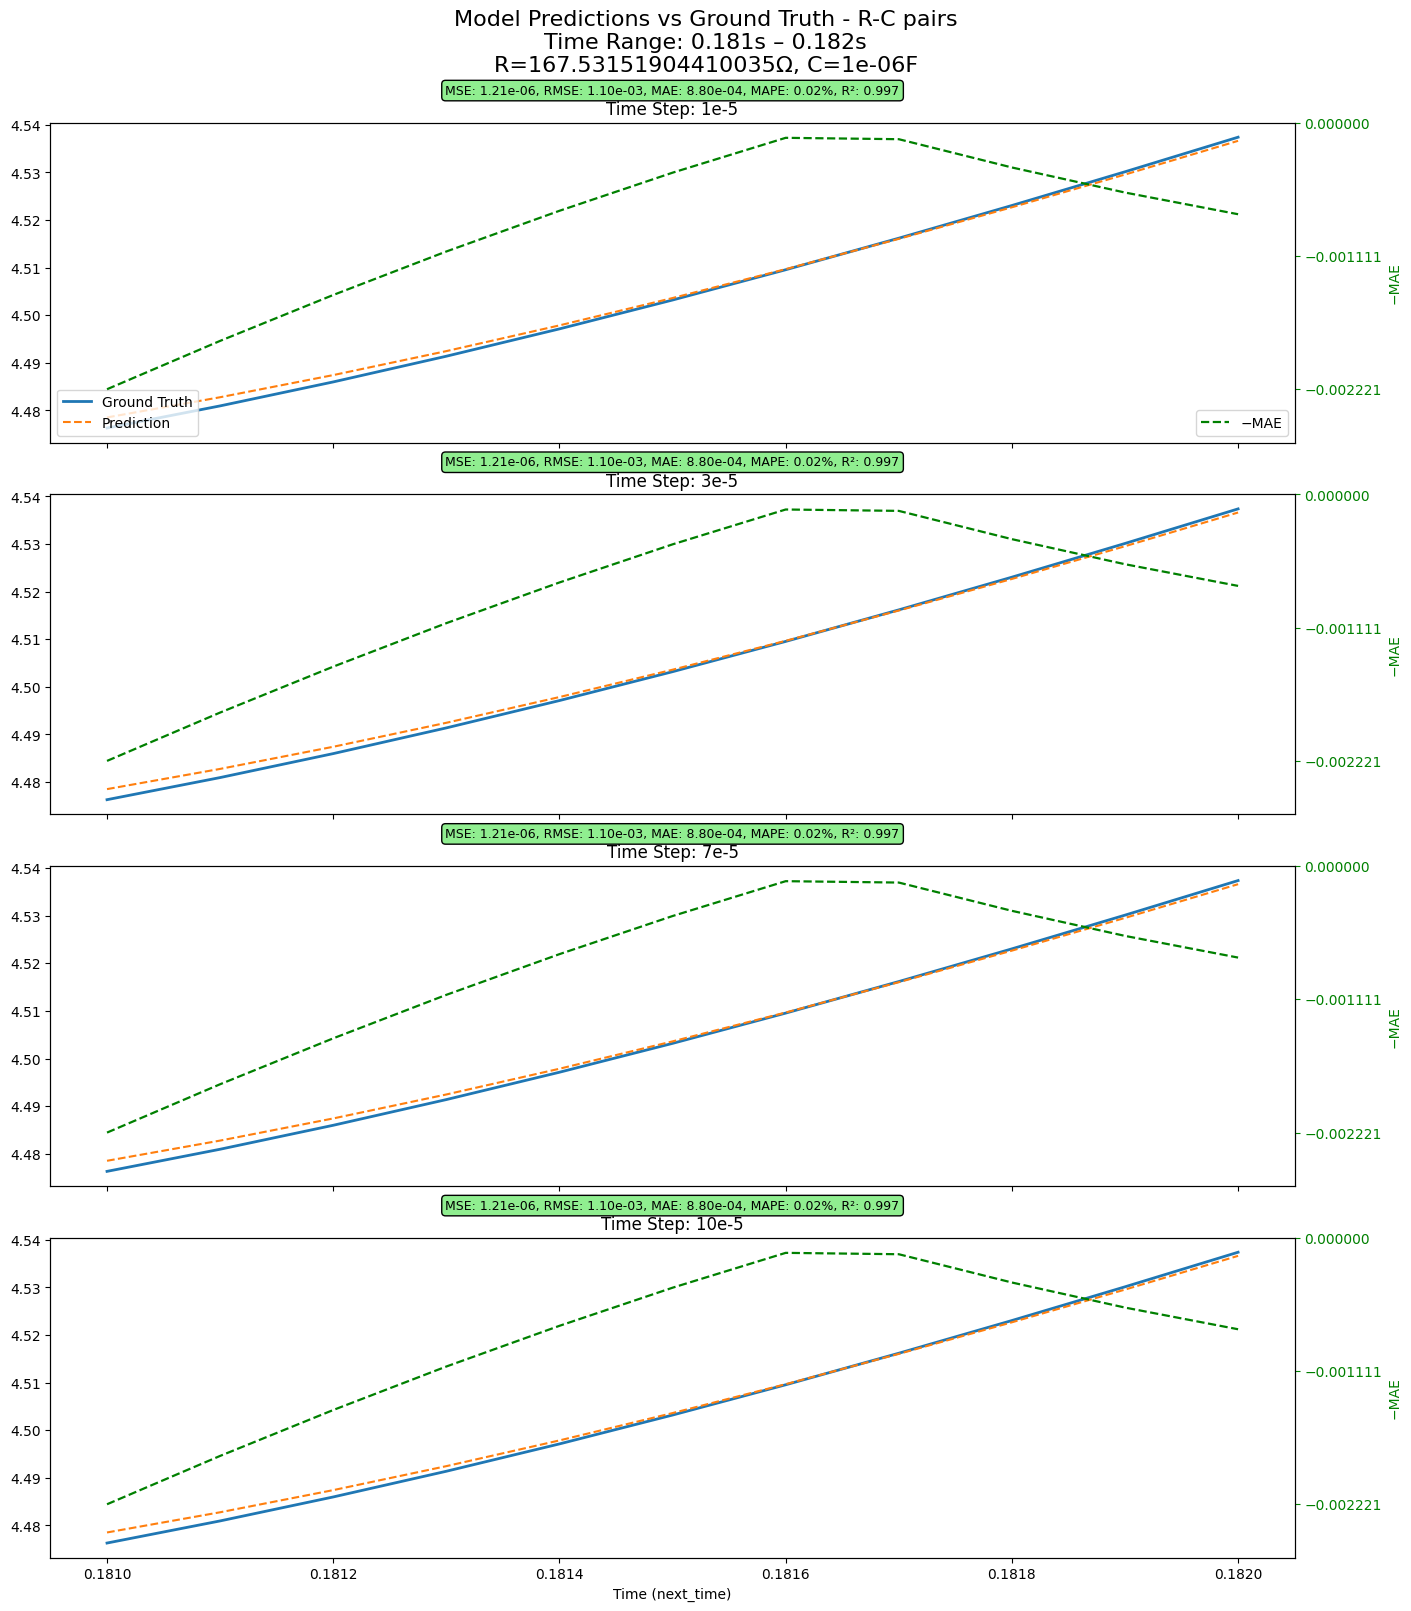

In [ ]:
import torch
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import re

# Load model
model = FeedforwardNet(hidden_layers=9, neurons_per_layer=48, input_size=2, output_size=1)
model.load_state_dict(torch.load("rectifier_sine_cosine_all_R-C_pairs_model__V(t)_h.pth"))
model.eval()

# Dataset list
# Datasets
# Dataset list
df_list = [
    'new_rectifier_results_R=167.53151904410035_C=1e-06__time_step_1e-5.csv',
    'new_rectifier_results_R=167.53151904410035_C=1e-06__time_step_3e-5.csv',
    'new_rectifier_results_R=167.53151904410035_C=1e-06__time_step_7e-5.csv',
    'new_rectifier_results_R=167.53151904410035_C=1e-06__time_step_10e-5.csv'
]

start_time = 0.181
end_time = 0.182

# Setup subplots with more breathing room
fig, axs = plt.subplots(len(df_list), 1, figsize=(14, 4 * len(df_list)), sharex=True, constrained_layout=True)

for i, f in enumerate(df_list):
    label = f.split("_time_step_")[-1].replace(".csv", "")
    df = pd.read_csv(f)

    
    y_true = df["next_value"].values
    next_time = df["next_time"].values

    time = data_df["time"].values.astype("float32")
    y_true_all = data_df["next_value"].values.astype("float32")
    value = data_df["value"].values.astype("float32")
    next_time = data_df["next_time"].values.astype("float32")
    delta_t = next_time - time
    X_all = np.stack([delta_t, value, ], axis=1).astype("float32")
    
    X_tensor = torch.tensor(X_all)

    with torch.no_grad():
        y_pred = model(X_tensor).squeeze().cpu().numpy()

    mask = (next_time >= start_time) & (next_time <= end_time)

    y_t = y_true_all[mask]
    y_p = y_pred[mask]
    t = next_time[mask]

    mse = mean_squared_error(y_t, y_p)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_t, y_p)
    mape = np.mean(np.abs((y_t - y_p) / y_t)) * 100 if not np.any(y_t == 0) else np.nan
    r2 = r2_score(y_t, y_p)

    ax = axs[i]
    ax.plot(t, y_t, label="Ground Truth", linewidth=2)
    ax.plot(t, y_p, label="Prediction", linestyle="--")
    ax.set_title(f"Time Step: {label}")

    # Error metrics box
    error_text = f"MSE: {mse:.2e}, RMSE: {rmse:.2e}, MAE: {mae:.2e}, MAPE: {mape:.2f}%, R²: {r2:.3f}"
    # Choose color based on R² value
    if r2 >= 0.95:
        box_color = 'lightgreen'
    elif r2 >= 0.5:
        box_color = 'orange'
    else:
        box_color = 'lightcoral'

    # Display error metrics box at top-center, slightly above plot
    ax.text(0.5, 1.08, error_text,
            transform=ax.transAxes,
            fontsize=9,
            ha='center',
            va='bottom',
            bbox=dict(boxstyle="round,pad=0.3", facecolor=box_color, edgecolor='black'))


    # Plot negative MAE
    ax2 = ax.twinx()
    nmae_values = -np.abs(y_t - y_p)
    ax2.plot(t, nmae_values, linestyle='--', linewidth=1.6, color='green', label='−MAE')
    ax2.set_ylim(nmae_values.min() * 1.2, 0)
    ax2.set_ylabel("−MAE", color='green', fontsize=10)
    ax2.tick_params(axis='y', colors='green')
    ax2.yaxis.label.set_color('green')
    ax2.set_yticks(np.linspace(nmae_values.min(), 0, 3))  # add 3 ticks for context

    if i == 0:
        ax.legend(loc='lower left')
        ax2.legend(loc='lower right')

# Extract R and C from filename
match = re.search(r"R=(?P<R>[\d.]+)_C=(?P<C>[\d.eE+-]+)", df_list[0])

R_val, C_val = (match.group("R"), match.group("C")) if match else ("unknown", "unknown")
safe_R_val = re.sub(r'[\\/*?:"<>|]', '_', R_val)
safe_C_val = re.sub(r'[\\/*?:"<>|]', '_', C_val)

axs[-1].set_xlabel("Time (next_time)")
fig.suptitle(f"Model Predictions vs Ground Truth - R-C pairs\nTime Range: {start_time}s – {end_time}s\nR={R_val}Ω, C={C_val}F", fontsize=16)
# Save the figure first
plt.savefig(f'rectifier_R{R_val}R{C_val}_R-C_pairs_v(t)_h.png', dpi=300)

# Then display it
plt.show()



In [ ]:
print(f"R_val: {safe_R_val}, C_val: {safe_C_val}")
import re

# Convert and sanitize R_val and C_val to safe strings
safe_R_val = re.sub(r'[\\/*?:"<>|]', '_', str(R_val))
safe_C_val = re.sub(r'[\\/*?:"<>|]', '_', str(C_val))

filename = f'R{safe_R_val}R{safe_C_val}_R-C_pairs.png'
plt.savefig(filename, dpi=300)


R_val: _, C_val: _


<Figure size 640x480 with 0 Axes>

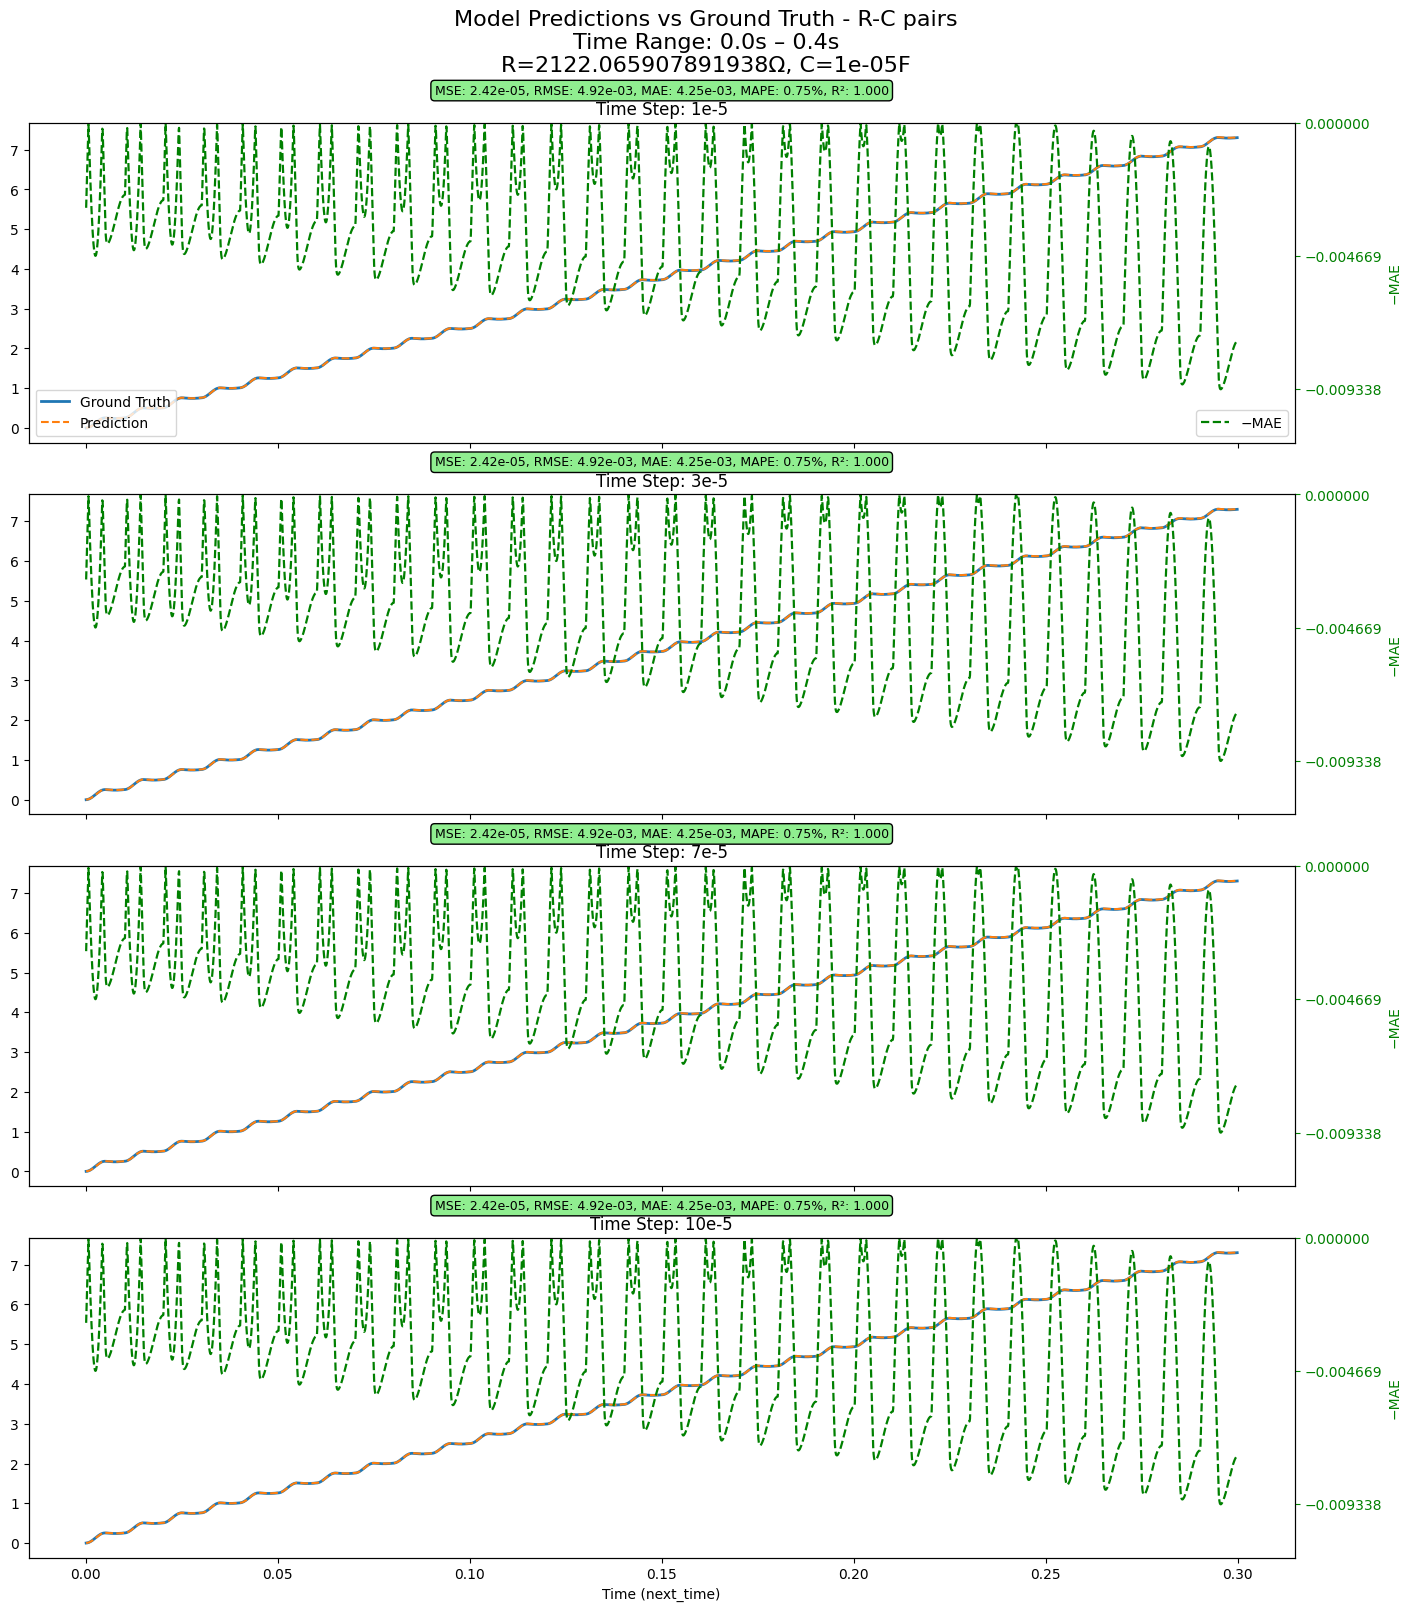

In [ ]:
import torch
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import re

# Load model
model = FeedforwardNet(hidden_layers=9, neurons_per_layer=48, input_size=2, output_size=1)
model.load_state_dict(torch.load("rectifier_sine_cosine_all_R-C_pairs_model__V(t)_h.pth"))
model.eval()

# Dataset list
# Datasets
# Dataset list
df_list = [
    'new_rectifier_results_R=2122.065907891938_C=1e-05__time_step_1e-5.csv',
    'new_rectifier_results_R=2122.065907891938_C=1e-05__time_step_3e-5.csv',
    'new_rectifier_results_R=2122.065907891938_C=1e-05__time_step_7e-5.csv',
    'new_rectifier_results_R=2122.065907891938_C=1e-05__time_step_10e-5.csv',
]

start_time = 0.0
end_time = 0.4

# Setup subplots with more breathing room
fig, axs = plt.subplots(len(df_list), 1, figsize=(14, 4 * len(df_list)), sharex=True, constrained_layout=True)

for i, f in enumerate(df_list):
    label = f.split("_time_step_")[-1].replace(".csv", "")
    df = pd.read_csv(f)

    
    y_true = df["next_value"].values
    next_time = df["next_time"].values

    time = data_df["time"].values.astype("float32")
    y_true_all = data_df["next_value"].values.astype("float32")
    value = data_df["value"].values.astype("float32")
    next_time = data_df["next_time"].values.astype("float32")
    delta_t = next_time - time
    X_all = np.stack([delta_t, value, ], axis=1).astype("float32")
    
    X_tensor = torch.tensor(X_all)

    with torch.no_grad():
        y_pred = model(X_tensor).squeeze().cpu().numpy()

    mask = (next_time >= start_time) & (next_time <= end_time)

    y_t = y_true_all[mask]
    y_p = y_pred[mask]
    t = next_time[mask]

    mse = mean_squared_error(y_t, y_p)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_t, y_p)
    mape = np.mean(np.abs((y_t - y_p) / y_t)) * 100 if not np.any(y_t == 0) else np.nan
    r2 = r2_score(y_t, y_p)

    ax = axs[i]
    ax.plot(t, y_t, label="Ground Truth", linewidth=2)
    ax.plot(t, y_p, label="Prediction", linestyle="--")
    ax.set_title(f"Time Step: {label}")

    # Error metrics box
    error_text = f"MSE: {mse:.2e}, RMSE: {rmse:.2e}, MAE: {mae:.2e}, MAPE: {mape:.2f}%, R²: {r2:.3f}"
    # Choose color based on R² value
    if r2 >= 0.95:
        box_color = 'lightgreen'
    elif r2 >= 0.5:
        box_color = 'orange'
    else:
        box_color = 'lightcoral'

    # Display error metrics box at top-center, slightly above plot
    ax.text(0.5, 1.08, error_text,
            transform=ax.transAxes,
            fontsize=9,
            ha='center',
            va='bottom',
            bbox=dict(boxstyle="round,pad=0.3", facecolor=box_color, edgecolor='black'))


    # Plot negative MAE
    ax2 = ax.twinx()
    nmae_values = -np.abs(y_t - y_p)
    ax2.plot(t, nmae_values, linestyle='--', linewidth=1.6, color='green', label='−MAE')
    ax2.set_ylim(nmae_values.min() * 1.2, 0)
    ax2.set_ylabel("−MAE", color='green', fontsize=10)
    ax2.tick_params(axis='y', colors='green')
    ax2.yaxis.label.set_color('green')
    ax2.set_yticks(np.linspace(nmae_values.min(), 0, 3))  # add 3 ticks for context

    if i == 0:
        ax.legend(loc='lower left')
        ax2.legend(loc='lower right')

# Extract R and C from filename
match = re.search(r"R=(?P<R>[\d.]+)_C=(?P<C>[\d.eE+-]+)", df_list[0])

R_val, C_val = (match.group("R"), match.group("C")) if match else ("unknown", "unknown")
safe_R_val = re.sub(r'[\\/*?:"<>|]', '_', R_val)
safe_C_val = re.sub(r'[\\/*?:"<>|]', '_', C_val)

axs[-1].set_xlabel("Time (next_time)")
fig.suptitle(f"Model Predictions vs Ground Truth - R-C pairs\nTime Range: {start_time}s – {end_time}s\nR={R_val}Ω, C={C_val}F", fontsize=16)
# Save the figure first
plt.savefig(f'rectifier_R{R_val}R{C_val}_R-C_pairs_v(t)_h.png', dpi=300)

# Then display it
plt.show()



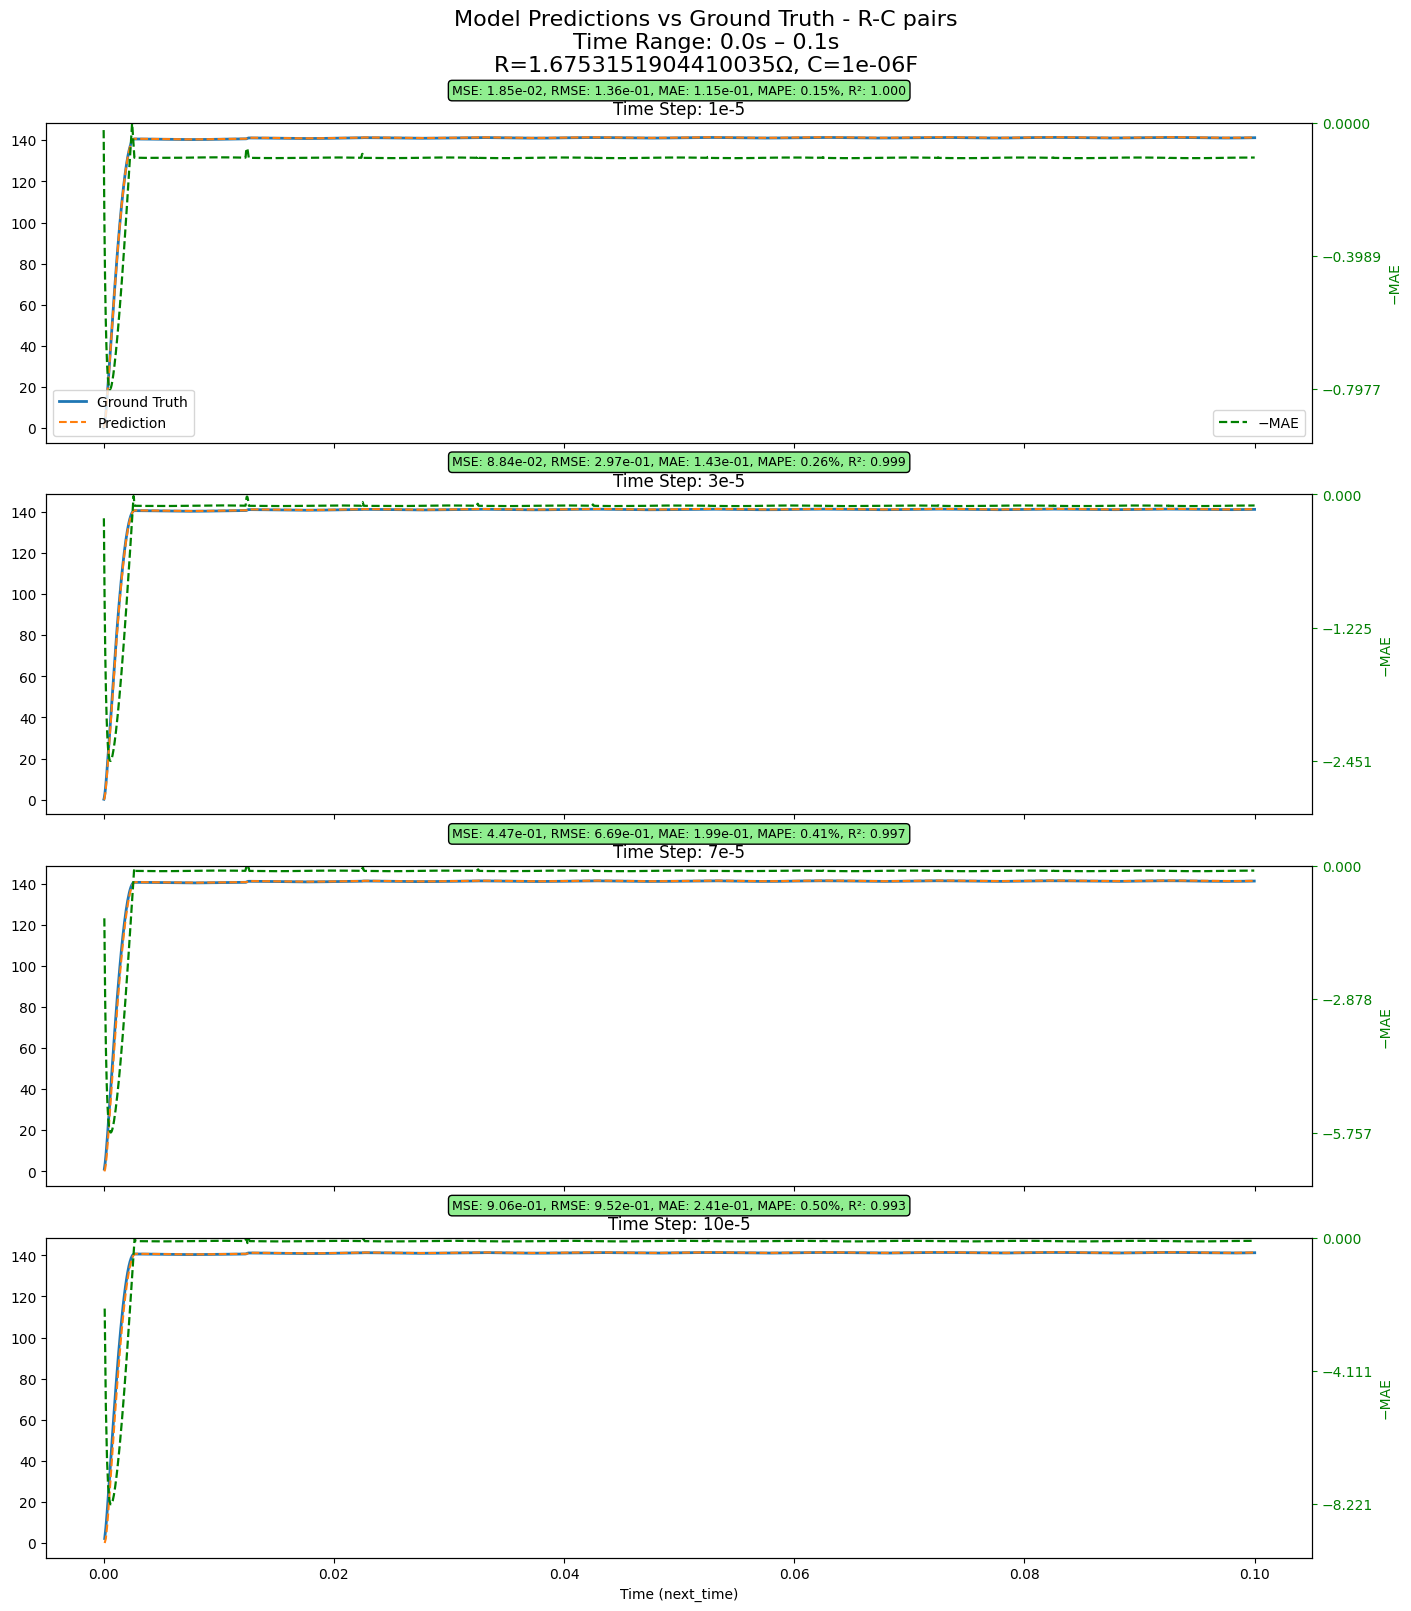

In [19]:
import torch
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import re

# Load model
model = FeedforwardNet(hidden_layers=9, neurons_per_layer=48, input_size=2, output_size=1)
model.load_state_dict(torch.load("rectifier_sine_cosine_all_R-C_pairs_model__V(t)_h.pth"))
model.eval()

# Dataset list
df_list = [
   "new_rectifier_results_R=1.6753151904410035_C=1e-06__time_step_1e-5.csv",
   "new_rectifier_results_R=1.6753151904410035_C=1e-06__time_step_3e-5.csv",
   "new_rectifier_results_R=1.6753151904410035_C=1e-06__time_step_7e-5.csv",
   "new_rectifier_results_R=1.6753151904410035_C=1e-06__time_step_10e-5.csv"
]


start_time = 0.0
end_time = 0.1

# Setup subplots with more breathing room
fig, axs = plt.subplots(len(df_list), 1, figsize=(14, 4 * len(df_list)), sharex=True, constrained_layout=True)

for i, f in enumerate(df_list):
    label = f.split("_time_step_")[-1].replace(".csv", "")
    df = pd.read_csv(f)

    y_true = df["next_value"].values
    next_time = df["next_time"].values

    time = df["time"].values.astype("float32")
    y_true_all = df["next_value"].values.astype("float32")
    value = df["value"].values.astype("float32")
    next_time = df["next_time"].values.astype("float32")
    delta_t = next_time - time
    X_all = np.stack([delta_t, value, ], axis=1).astype("float32")
    

    X_tensor = torch.tensor(X_all)
    with torch.no_grad():
        y_pred = model(X_tensor).squeeze().cpu().numpy()

    mask = (next_time >= start_time) & (next_time <= end_time)

    y_t = y_true[mask]
    y_p = y_pred[mask]
    t = next_time[mask]

    mse = mean_squared_error(y_t, y_p)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_t, y_p)
    mape = np.mean(np.abs((y_t - y_p) / y_t)) * 100 if not np.any(y_t == 0) else np.nan
    r2 = r2_score(y_t, y_p)

    ax = axs[i]
    ax.plot(t, y_t, label="Ground Truth", linewidth=2)
    ax.plot(t, y_p, label="Prediction", linestyle="--")
    ax.set_title(f"Time Step: {label}")

    # Error metrics box
    error_text = f"MSE: {mse:.2e}, RMSE: {rmse:.2e}, MAE: {mae:.2e}, MAPE: {mape:.2f}%, R²: {r2:.3f}"
    # Choose color based on R² value
    if r2 >= 0.95:
        box_color = 'lightgreen'
    elif r2 >= 0.5:
        box_color = 'orange'
    else:
        box_color = 'lightcoral'

    # Display error metrics box at top-center, slightly above plot
    ax.text(0.5, 1.08, error_text,
            transform=ax.transAxes,
            fontsize=9,
            ha='center',
            va='bottom',
            bbox=dict(boxstyle="round,pad=0.3", facecolor=box_color, edgecolor='black'))


    # Plot negative MAE
    ax2 = ax.twinx()
    nmae_values = -np.abs(y_t - y_p)
    ax2.plot(t, nmae_values, linestyle='--', linewidth=1.6, color='green', label='−MAE')
    ax2.set_ylim(nmae_values.min() * 1.2, 0)
    ax2.set_ylabel("−MAE", color='green', fontsize=10)
    ax2.tick_params(axis='y', colors='green')
    ax2.yaxis.label.set_color('green')
    ax2.set_yticks(np.linspace(nmae_values.min(), 0, 3))  # add 3 ticks for context

    if i == 0:
        ax.legend(loc='lower left')
        ax2.legend(loc='lower right')

# Extract R and C from filename
# Extract R and C from filename
match = re.search(r"R=(?P<R>[\d.]+)_C=(?P<C>[\d.eE+-]+)", df_list[0])

R_val, C_val = (match.group("R"), match.group("C")) if match else ("unknown", "unknown")
safe_R_val = re.sub(r'[\\/*?:"<>|]', '_', R_val)
safe_C_val = re.sub(r'[\\/*?:"<>|]', '_', C_val)

axs[-1].set_xlabel("Time (next_time)")
fig.suptitle(f"Model Predictions vs Ground Truth - R-C pairs\nTime Range: {start_time}s – {end_time}s\nR={R_val}Ω, C={C_val}F", fontsize=16)
# Save the figure first
plt.savefig(f'rectifier_R{safe_R_val}R{safe_C_val}_R-C_pairs_v(t)_h.png', dpi=300)

# Then display it
plt.show()


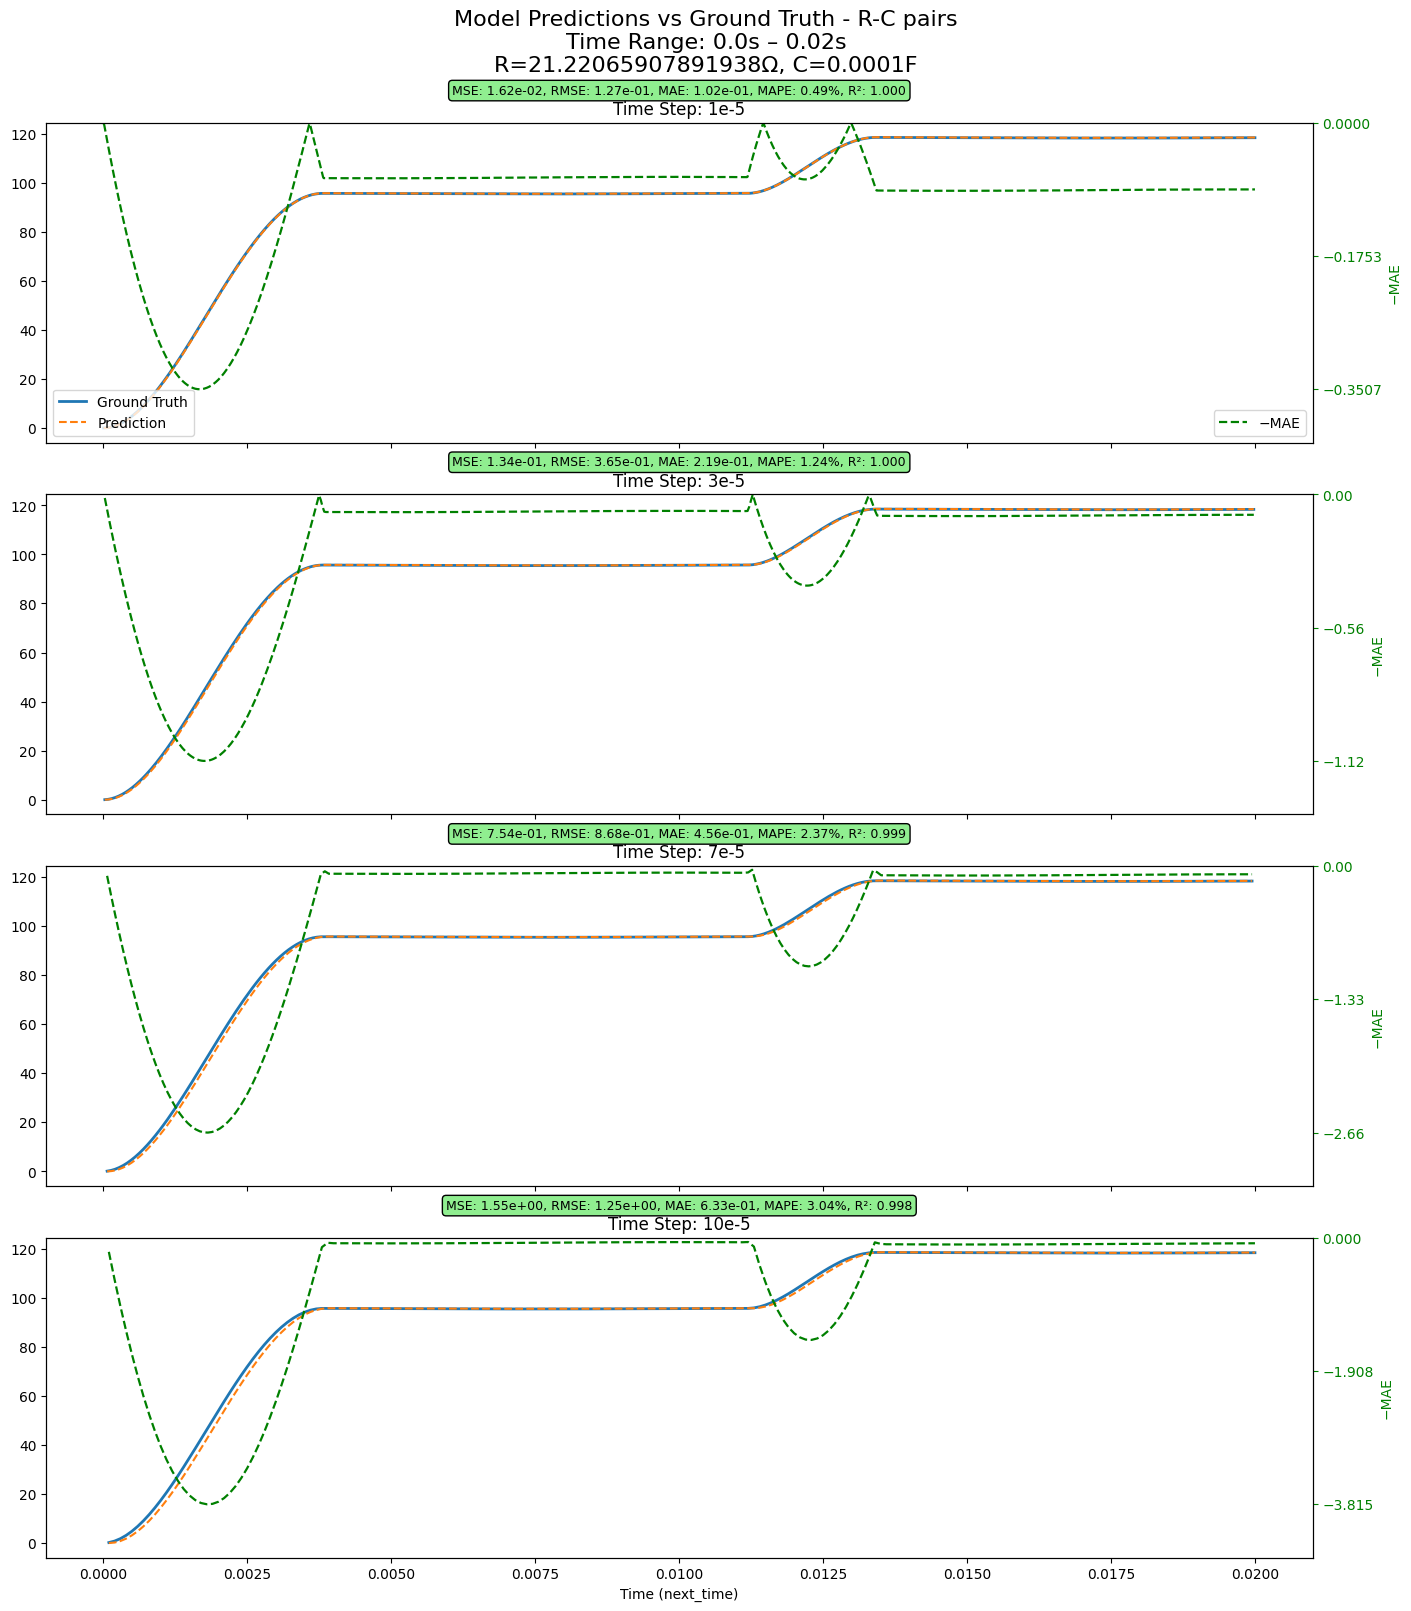

In [23]:
import torch
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import re

# Load model
model = FeedforwardNet(hidden_layers=9, neurons_per_layer=48, input_size=2, output_size=1)
model.load_state_dict(torch.load("rectifier_sine_cosine_all_R-C_pairs_model__V(t)_h.pth"))
model.eval()

# Dataset list
df_list = [
   "new_rectifier_results_R=21.22065907891938_C=0.0001__time_step_1e-5.csv",
   "new_rectifier_results_R=21.22065907891938_C=0.0001__time_step_3e-5.csv",
   "new_rectifier_results_R=21.22065907891938_C=0.0001__time_step_7e-5.csv",
   "new_rectifier_results_R=21.22065907891938_C=0.0001__time_step_10e-5.csv"
]


start_time = 0.0
end_time = 0.02

# Setup subplots with more breathing room
fig, axs = plt.subplots(len(df_list), 1, figsize=(14, 4 * len(df_list)), sharex=True, constrained_layout=True)

for i, f in enumerate(df_list):
    label = f.split("_time_step_")[-1].replace(".csv", "")
    df = pd.read_csv(f)

    y_true = df["next_value"].values
    next_time = df["next_time"].values

    time = df["time"].values.astype("float32")
    y_true_all = df["next_value"].values.astype("float32")
    value = df["value"].values.astype("float32")
    next_time = df["next_time"].values.astype("float32")
    delta_t = next_time - time
    X_all = np.stack([delta_t, value, ], axis=1).astype("float32")
    

    X_tensor = torch.tensor(X_all)
    with torch.no_grad():
        y_pred = model(X_tensor).squeeze().cpu().numpy()

    mask = (next_time >= start_time) & (next_time <= end_time)

    y_t = y_true[mask]
    y_p = y_pred[mask]
    t = next_time[mask]

    mse = mean_squared_error(y_t, y_p)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_t, y_p)
    mape = np.mean(np.abs((y_t - y_p) / y_t)) * 100 if not np.any(y_t == 0) else np.nan
    r2 = r2_score(y_t, y_p)

    ax = axs[i]
    ax.plot(t, y_t, label="Ground Truth", linewidth=2)
    ax.plot(t, y_p, label="Prediction", linestyle="--")
    ax.set_title(f"Time Step: {label}")

    # Error metrics box
    error_text = f"MSE: {mse:.2e}, RMSE: {rmse:.2e}, MAE: {mae:.2e}, MAPE: {mape:.2f}%, R²: {r2:.3f}"
    # Choose color based on R² value
    if r2 >= 0.95:
        box_color = 'lightgreen'
    elif r2 >= 0.5:
        box_color = 'orange'
    else:
        box_color = 'lightcoral'

    # Display error metrics box at top-center, slightly above plot
    ax.text(0.5, 1.08, error_text,
            transform=ax.transAxes,
            fontsize=9,
            ha='center',
            va='bottom',
            bbox=dict(boxstyle="round,pad=0.3", facecolor=box_color, edgecolor='black'))


    # Plot negative MAE
    ax2 = ax.twinx()
    nmae_values = -np.abs(y_t - y_p)
    ax2.plot(t, nmae_values, linestyle='--', linewidth=1.6, color='green', label='−MAE')
    ax2.set_ylim(nmae_values.min() * 1.2, 0)
    ax2.set_ylabel("−MAE", color='green', fontsize=10)
    ax2.tick_params(axis='y', colors='green')
    ax2.yaxis.label.set_color('green')
    ax2.set_yticks(np.linspace(nmae_values.min(), 0, 3))  # add 3 ticks for context

    if i == 0:
        ax.legend(loc='lower left')
        ax2.legend(loc='lower right')

# Extract R and C from filename
# Extract R and C from filename
match = re.search(r"R=(?P<R>[\d.]+)_C=(?P<C>[\d.eE+-]+)", df_list[0])

R_val, C_val = (match.group("R"), match.group("C")) if match else ("unknown", "unknown")
safe_R_val = re.sub(r'[\\/*?:"<>|]', '_', R_val)
safe_C_val = re.sub(r'[\\/*?:"<>|]', '_', C_val)

axs[-1].set_xlabel("Time (next_time)")
fig.suptitle(f"Model Predictions vs Ground Truth - R-C pairs\nTime Range: {start_time}s – {end_time}s\nR={R_val}Ω, C={C_val}F", fontsize=16)
# Save the figure first
plt.savefig(f'rectifier_R{safe_R_val}R{safe_C_val}_R-C_pairs_v(t)_h.png', dpi=300)

# Then display it
plt.show()


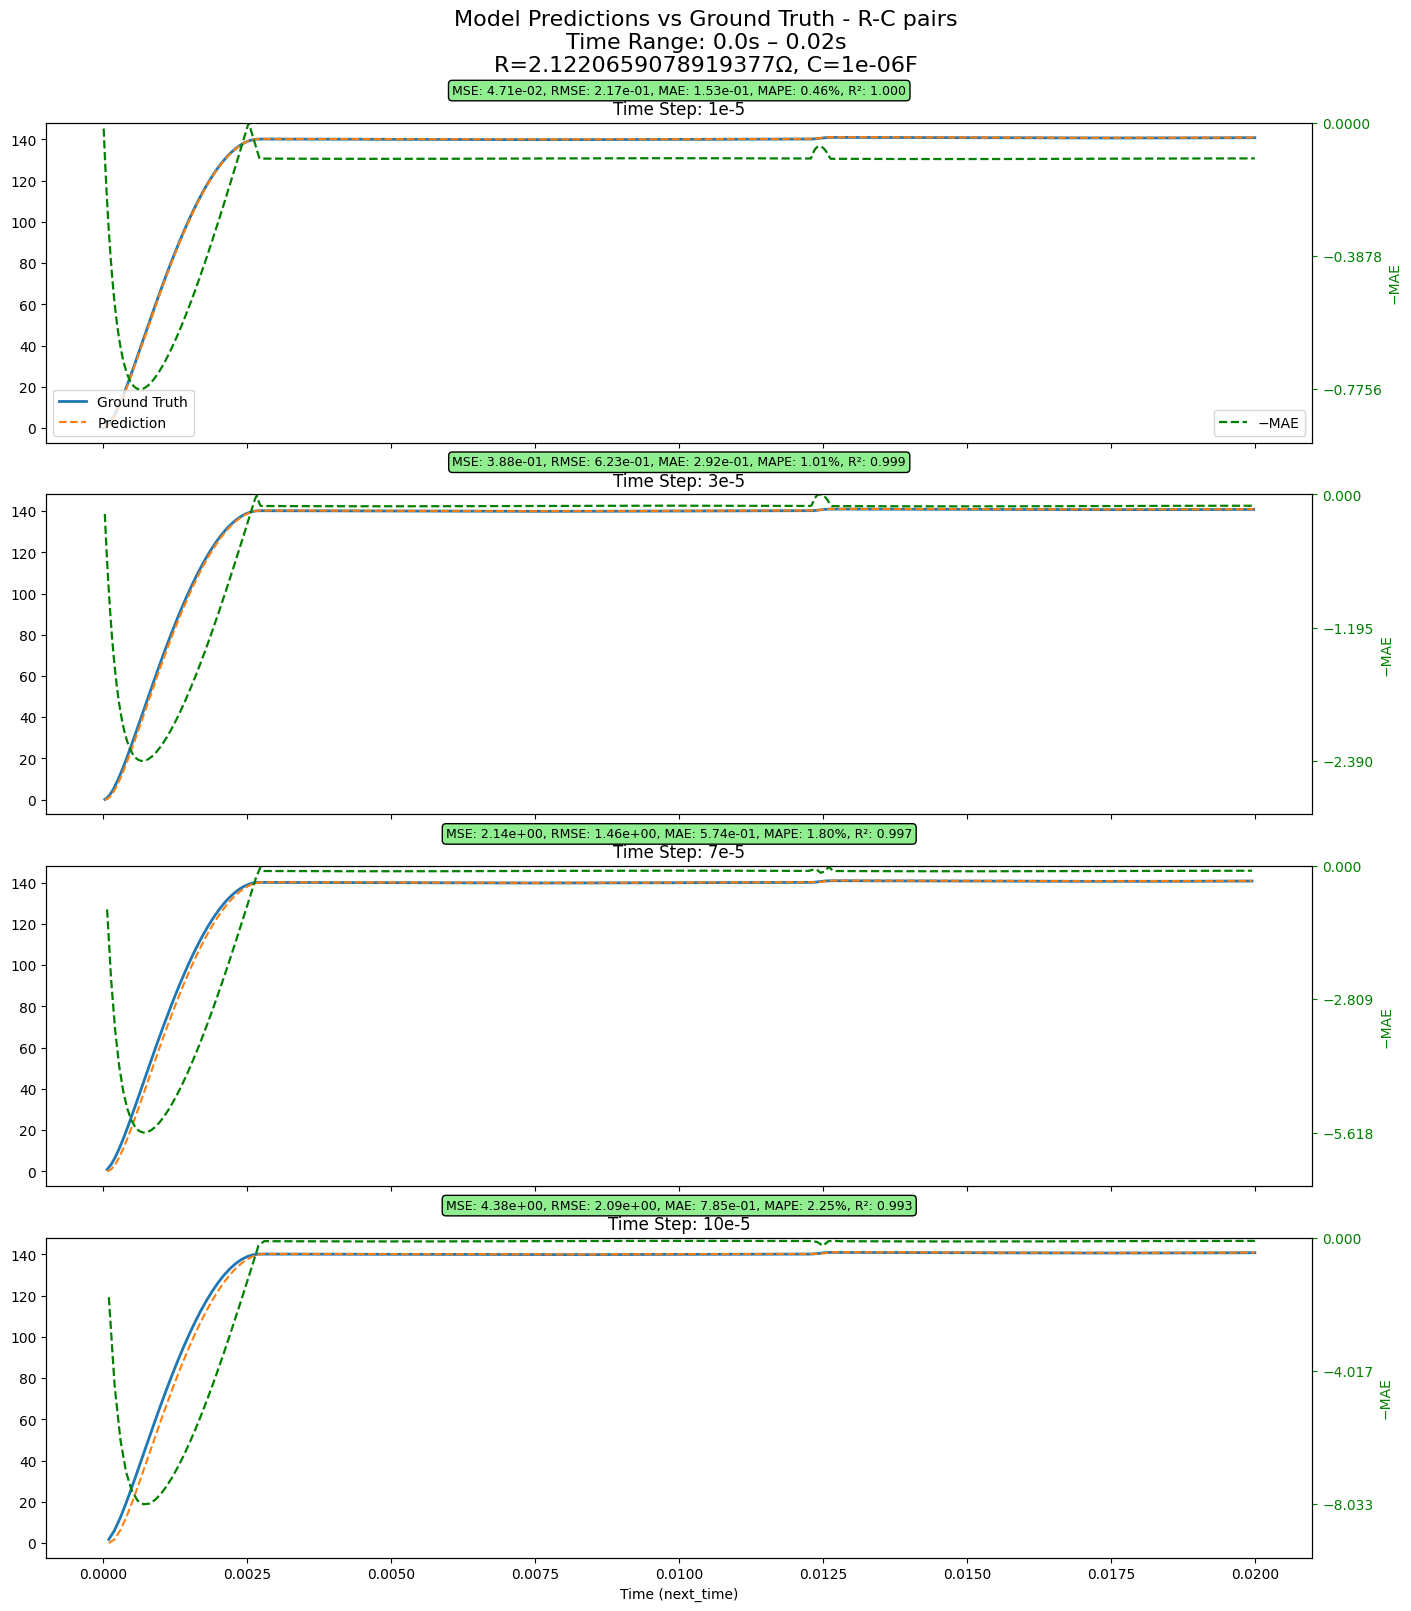

In [28]:
import torch
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import re

# Load model
model = FeedforwardNet(hidden_layers=9, neurons_per_layer=48, input_size=2, output_size=1)
model.load_state_dict(torch.load("rectifier_sine_cosine_all_R-C_pairs_model__V(t)_h.pth"))
model.eval()

# Dataset list
df_list = [
   "new_rectifier_results_R=2.1220659078919377_C=1e-06__time_step_1e-5.csv",
   "new_rectifier_results_R=2.1220659078919377_C=1e-06__time_step_3e-5.csv",
   "new_rectifier_results_R=2.1220659078919377_C=1e-06__time_step_7e-5.csv",
   "new_rectifier_results_R=2.1220659078919377_C=1e-06__time_step_10e-5.csv"
]


start_time = 0.0
end_time = 0.02

# Setup subplots with more breathing room
fig, axs = plt.subplots(len(df_list), 1, figsize=(14, 4 * len(df_list)), sharex=True, constrained_layout=True)

for i, f in enumerate(df_list):
    label = f.split("_time_step_")[-1].replace(".csv", "")
    df = pd.read_csv(f)

    y_true = df["next_value"].values
    next_time = df["next_time"].values

    time = df["time"].values.astype("float32")
    y_true_all = df["next_value"].values.astype("float32")
    value = df["value"].values.astype("float32")
    next_time = df["next_time"].values.astype("float32")
    delta_t = next_time - time
    X_all = np.stack([delta_t, value, ], axis=1).astype("float32")
    

    X_tensor = torch.tensor(X_all)
    with torch.no_grad():
        y_pred = model(X_tensor).squeeze().cpu().numpy()

    mask = (next_time >= start_time) & (next_time <= end_time)

    y_t = y_true[mask]
    y_p = y_pred[mask]
    t = next_time[mask]

    mse = mean_squared_error(y_t, y_p)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_t, y_p)
    mape = np.mean(np.abs((y_t - y_p) / y_t)) * 100 if not np.any(y_t == 0) else np.nan
    r2 = r2_score(y_t, y_p)

    ax = axs[i]
    ax.plot(t, y_t, label="Ground Truth", linewidth=2)
    ax.plot(t, y_p, label="Prediction", linestyle="--")
    ax.set_title(f"Time Step: {label}")

    # Error metrics box
    error_text = f"MSE: {mse:.2e}, RMSE: {rmse:.2e}, MAE: {mae:.2e}, MAPE: {mape:.2f}%, R²: {r2:.3f}"
    # Choose color based on R² value
    if r2 >= 0.95:
        box_color = 'lightgreen'
    elif r2 >= 0.5:
        box_color = 'orange'
    else:
        box_color = 'lightcoral'

    # Display error metrics box at top-center, slightly above plot
    ax.text(0.5, 1.08, error_text,
            transform=ax.transAxes,
            fontsize=9,
            ha='center',
            va='bottom',
            bbox=dict(boxstyle="round,pad=0.3", facecolor=box_color, edgecolor='black'))


    # Plot negative MAE
    ax2 = ax.twinx()
    nmae_values = -np.abs(y_t - y_p)
    ax2.plot(t, nmae_values, linestyle='--', linewidth=1.6, color='green', label='−MAE')
    ax2.set_ylim(nmae_values.min() * 1.2, 0)
    ax2.set_ylabel("−MAE", color='green', fontsize=10)
    ax2.tick_params(axis='y', colors='green')
    ax2.yaxis.label.set_color('green')
    ax2.set_yticks(np.linspace(nmae_values.min(), 0, 3))  # add 3 ticks for context

    if i == 0:
        ax.legend(loc='lower left')
        ax2.legend(loc='lower right')

# Extract R and C from filename
# Extract R and C from filename
match = re.search(r"R=(?P<R>[\d.]+)_C=(?P<C>[\d.eE+-]+)", df_list[0])

R_val, C_val = (match.group("R"), match.group("C")) if match else ("unknown", "unknown")
safe_R_val = re.sub(r'[\\/*?:"<>|]', '_', R_val)
safe_C_val = re.sub(r'[\\/*?:"<>|]', '_', C_val)

axs[-1].set_xlabel("Time (next_time)")
fig.suptitle(f"Model Predictions vs Ground Truth - R-C pairs\nTime Range: {start_time}s – {end_time}s\nR={R_val}Ω, C={C_val}F", fontsize=16)
# Save the figure first
plt.savefig(f'rectifier_R{safe_R_val}R{safe_C_val}_R-C_pairs_v(t)_h.png', dpi=300)

# Then display it
plt.show()
